# 04. Custom MLP — Loan Default Prediction

**Research Questions addressed:**
- **RQ1:** How do different regularisation strategies (dropout, batch normalisation, early stopping)  affect predictive performance and model complexity?

**Sections:**

| Section | What it does |
|---|---|
| 4 — Base MLP (ReLU) | Sequential MLP with Dropout + BatchNorm + early stopping; training curves |
| 5 — Leaky ReLU comparison | Same architecture with Leaky ReLU; why it avoids dead neurons |
| 6 — Hyperparameter sweep | Dropout rate × BatchNorm × layer sizes × learning rate → results table |
| 7 — Regularisation ablation | 5 variants (none / dropout / BN / early-stop / all) → RQ1 table |
| 8 — SMOTE comparison | Best config trained on SMOTE vs original; precision/recall impact |
| 9 — Default DNN config | Final MLP following the published DNN defaults (SELU + LeCun + Nadam + LR schedule) |
| 13 — PCA data load | Load PCA-reduced splits from `03_processed_pca/`; convert to arrays |
| 14 — PCA: Base MLP (ReLU) | Retrain base ReLU MLP on PCA features |
| 15 — PCA: Leaky ReLU | Retrain Leaky ReLU MLP on PCA features |
| 16 — PCA: Best config | Retrain best sweep config (original + SMOTE) on PCA features |
| 17 — PCA vs Original | Comprehensive comparison table + ROC overlay |

**Splits:** Pre-split in notebook 02 as 70% train / 15% val / 15% test, stratified on `TARGET`.  
**Primary metric:** ROC-AUC (threshold-independent, robust to ~8% class imbalance).


## 0. Setup

In [1]:
import time
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}  |  tensorflow {tf.__version__}")

Libraries imported successfully.
numpy 2.0.2  |  pandas 2.2.2  |  tensorflow 2.20.0


## 1. Load Processed Data

Mount Google Drive and load all six splits produced by notebook 02.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR  = "/content/drive/MyDrive/MLDL/loan-default-project/01_data/02_processed"
MODEL_DIR = "/content/drive/MyDrive/MLDL/loan-default-project/03_models"
os.makedirs(MODEL_DIR, exist_ok=True)

#load all splits
X_train       = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_train_smote = pd.read_csv(f"{DATA_DIR}/X_train_smote.csv")
X_val         = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test        = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train       = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_train_smote = pd.read_csv(f"{DATA_DIR}/y_train_smote.csv").squeeze()
y_val         = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze()
y_test        = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

feature_names = pd.read_csv(f"{DATA_DIR}/feature_names.csv", header=None).squeeze().tolist()

#re-attach feature names
for df in [X_train, X_train_smote, X_val, X_test]:
    df.columns = feature_names

print("=== Shapes ===")
print(f"X_train       : {X_train.shape}")
print(f"X_train_smote : {X_train_smote.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test        : {X_test.shape}")
print(f"\n=== Target distribution ===")
print(f"Train (original) default rate : {y_train.mean():.4f}")
print(f"Train (SMOTE)    default rate : {y_train_smote.mean():.4f}")
print(f"Val              default rate : {y_val.mean():.4f}")
print(f"Test             default rate : {y_test.mean():.4f}")
print(f"\nNumber of features: {len(feature_names)}")

Mounted at /content/drive
=== Shapes ===
X_train       : (215253, 113)
X_train_smote : (395752, 113)
X_val         : (46126, 113)
X_test        : (46126, 113)

=== Target distribution ===
Train (original) default rate : 0.0807
Train (SMOTE)    default rate : 0.5000
Val              default rate : 0.0807
Test             default rate : 0.0807

Number of features: 113


## 2. Quick Sanity Checks

Confirm no residual NaNs and that column ordering is identical across all splits.

In [3]:
nan_counts = {
    "X_train"      : X_train.isna().sum().sum(),
    "X_train_smote": X_train_smote.isna().sum().sum(),
    "X_val"        : X_val.isna().sum().sum(),
    "X_test"       : X_test.isna().sum().sum(),
}
print("NaN counts per split:")
for k, v in nan_counts.items():
    status = "\u2713 clean" if v == 0 else f"\u26a0 {v} NaNs"
    print(f"  {k:20s}: {status}")

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "Feature column order mismatch across splits"
print("\n\u2713 Feature columns identical across all splits")

#convert to float32 arrays for Keras, halves memory vs float64
X_train_arr       = X_train.values.astype(np.float32)
X_train_smote_arr = X_train_smote.values.astype(np.float32)
X_val_arr         = X_val.values.astype(np.float32)
X_test_arr        = X_test.values.astype(np.float32)

y_train_arr       = y_train.values.astype(np.float32)
y_train_smote_arr = y_train_smote.values.astype(np.float32)
y_val_arr         = y_val.values.astype(np.float32)
y_test_arr        = y_test.values.astype(np.float32)

N_FEATURES = X_train_arr.shape[1]
print(f"\nInput dimensionality: {N_FEATURES} features")
print(f"dtype: {X_train_arr.dtype} (float32 — memory-efficient for GPU)")

NaN counts per split:
  X_train             : ✓ clean
  X_train_smote       : ✓ clean
  X_val               : ✓ clean
  X_test              : ✓ clean

✓ Feature columns identical across all splits

Input dimensionality: 113 features
dtype: float32 (float32 — memory-efficient for GPU)


## 3. Helper Functions

Centralised evaluation and plotting so every model variant is assessed identically.

In [4]:
def evaluate_keras_model(model, X, y, split_name="Val", threshold=0.3):
    """
    Compute and print key classification metrics for a Keras model.

    We use threshold=0.3 instead of the default 0.5.

    With ~8% defaults in the dataset, the model rarely outputs a probability
    above 0.5 for the minority class, so a fixed 0.5 cut-off almost always
    predicts "No Default" (class 0). Lowering the threshold to 0.3 means we
    flag an applicant as a default risk whenever the model assigns at least a
    30% probability of default. This is a natural choice in credit risk:
    a bank prefers to investigate a borderline case rather than miss a real
    defaulter, so a lower threshold is standard practice.

    Returns a dict with scalar metrics for easy tabulation.
    """
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {split_name} — threshold = {threshold}")
    print(f"{'='*55}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['No Default (0)', 'Default (1)'])}")

    return {"split": split_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


def plot_training_curves(history, title="Training curves"):
    """
    Plot loss and AUC vs epoch for train and validation.
    This is the primary overfitting / underfitting diagnostic.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train loss')
    axes[0].plot(history.history['val_loss'], label='Val loss')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].set_title("Loss")
    axes[0].legend()

    #AUC
    auc_key = 'auc' if 'auc' in history.history else list(
        [k for k in history.history if 'auc' in k and 'val' not in k])[0]
    val_auc_key = f'val_{auc_key}'
    axes[1].plot(history.history[auc_key],     label='Train AUC')
    axes[1].plot(history.history[val_auc_key], label='Val AUC')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("ROC-AUC")
    axes[1].set_title("AUC")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_evaluation_keras(model, X_val, y_val, X_test, y_test, title_prefix="", threshold=0.3):
    """
    Side-by-side: confusion matrix (val), ROC curve (val + test),
    and Precision-Recall curve (val + test).
    Uses threshold=0.3 to match evaluate_keras_model.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Evaluation Plots", fontsize=14, fontweight='bold')

    #Confusion matrix on validation set
    y_prob_val = model.predict(X_val, verbose=0).ravel()
    y_pred_val = (y_prob_val >= threshold).astype(int)
    cm = confusion_matrix(y_val, y_pred_val)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title(f"Confusion Matrix (Val, threshold={threshold})")

    #ROC curves (val and test)
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict(X, verbose=0).ravel()
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    #Precision-Recall curves (val and test)
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict(X, verbose=0).ravel()
        prec, rec, _ = precision_recall_curve(y, y_prob)
        ap = average_precision_score(y, y_prob)
        axes[2].plot(rec, prec, label=f"{label} (AP={ap:.4f})")
    baseline_rate = y_val.mean()
    axes[2].axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8,
                    label=f"Random baseline ({baseline_rate:.3f})")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


print("Helper functions defined.")

Helper functions defined.


## 4. Base MLP — ReLU + Dropout + BatchNorm + Early Stopping

We start with a clean three-layer MLP as our reference architecture:
- **Activation:** ReLU (Rectified Linear Unit), fast and avoids the vanishing gradient problem
  compared to sigmoid/tanh in hidden layers. Gradient is either 0 (negative input) or 1 (positive),
  so it does not saturate for large activations.
- **Dropout:** Applied after each hidden layer to randomly zero a fraction of activations during
  training, forcing the network to learn redundant representations. Equivalent to training an
  ensemble of thinned networks.
- **BatchNorm:** Normalises each mini-batch's activations to zero mean / unit variance before
  the activation function. Reduces internal covariate shift, allows higher learning rates, and
  acts as a mild regulariser.
- **Early Stopping:** Monitors `val_auc` and stops when it stops improving, restoring the
  best weights. This limits effective model complexity and is our primary defence against
  overfitting.
- **Optimizer:** Adam, adaptive learning rate per parameter, generally the best default
  for tabular data.

### 4.1 Build and train the base MLP

### Class imbalance fix: `class_weight` in `model.fit()`

The training set has ~8% defaults. Without correction, binary cross-entropy treats every sample equally, so the model quickly learns that predicting **always class 0** minimises loss (92% accuracy but 0% recall on defaulters).

`class_weight` re-scales the per-sample loss so that a mistake on a defaulter counts proportionally more than a mistake on a non-defaulter — equivalent to up-weighting the minority class without changing the data.

We compute the weights automatically from the training labels:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_c}$$

This is identical to `sklearn`'s `class_weight='balanced'` formula.

In [5]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_arr)
weights = compute_class_weight('balanced', classes=classes, y=y_train_arr)
CLASS_WEIGHT = dict(zip(classes.astype(int), weights))

print(f"Class weights: {CLASS_WEIGHT}")
print(f"  Weight for class 0 (no default) : {CLASS_WEIGHT[0]:.4f}")
print(f"  Weight for class 1 (default)    : {CLASS_WEIGHT[1]:.4f}")
print(f"  Ratio (imbalance factor)        : {CLASS_WEIGHT[1]/CLASS_WEIGHT[0]:.1f}x")

Class weights: {np.int64(0): np.float64(0.5439088115789686), np.int64(1): np.float64(6.193618000805663)}
  Weight for class 0 (no default) : 0.5439
  Weight for class 1 (default)    : 6.1936
  Ratio (imbalance factor)        : 11.4x


In [6]:
def build_mlp_relu(n_features, hidden_units=(128, 64), dropout_rate=0.3,
                   use_batchnorm=True, learning_rate=0.001):
    """
    Input -> [Dense -> BatchNorm (optional) -> ReLU -> Dropout] x N -> Dense(1, sigmoid)

    Parameters
    ----------
    n_features    : int   — number of input features
    hidden_units  : tuple — neurons per hidden layer
    dropout_rate  : float — fraction of units to drop per hidden layer
    use_batchnorm : bool  — insert BatchNormalization before each activation
    learning_rate : float — Adam initial learning rate
    """
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential(name="MLP_ReLU")
    model.add(layers.Input(shape=(n_features,)))

    for units in hidden_units:
        model.add(layers.Dense(units, use_bias=not use_batchnorm))  # bias redundant with BN
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate, seed=SEED))

    #sigmoid output: produces a probability score for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model


#instantiate and inspect
base_model = build_mlp_relu(N_FEATURES, hidden_units=(128, 64), dropout_rate=0.3,
                             use_batchnorm=True, learning_rate=0.001)
base_model.summary()

Model: "MLP_ReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,489 (91.75 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
#callbacks
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

#train
print("Training base MLP (ReLU, dropout=0.3, BatchNorm, Adam lr=0.001)...")
t0 = time.time()

history_base = base_model.fit(
    X_train_arr, y_train_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop],
    class_weight=CLASS_WEIGHT,   #re-weight minority class — prevents always predicting class 0
    verbose=1
)

train_time_base = time.time() - t0
print(f"\nTraining time: {train_time_base:.1f}s")
print(f"Stopped at epoch: {early_stop.stopped_epoch + 1 if early_stop.stopped_epoch > 0 else len(history_base.history['loss'])}")

Training base MLP (ReLU, dropout=0.3, BatchNorm, Adam lr=0.001)...
Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - auc: 0.6800 - loss: 0.6658 - val_auc: 0.7432 - val_loss: 0.6348
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7272 - loss: 0.6140 - val_auc: 0.7492 - val_loss: 0.6221
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7393 - loss: 0.6021 - val_auc: 0.7514 - val_loss: 0.6224
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7445 - loss: 0.5973 - val_auc: 0.7525 - val_loss: 0.6279
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7484 - loss: 0.5936 - val_auc: 0.7533 - val_loss: 0.6295
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7509 - loss: 0.5916 - val_auc: 0.7539 - val_loss: 0.6216
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7512 - loss: 0.5909 - val_auc: 0.7544 - val_loss: 0.6246
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.7551 - loss: 0.5875 - val_auc: 0.754

### 4.2 Training curves

The key overfitting / underfitting diagnostic. A well-regularised model should show:
- Train loss decreasing steadily, val loss following closely and plateauing (not diverging).
- Train AUC and val AUC converging rather than separating.

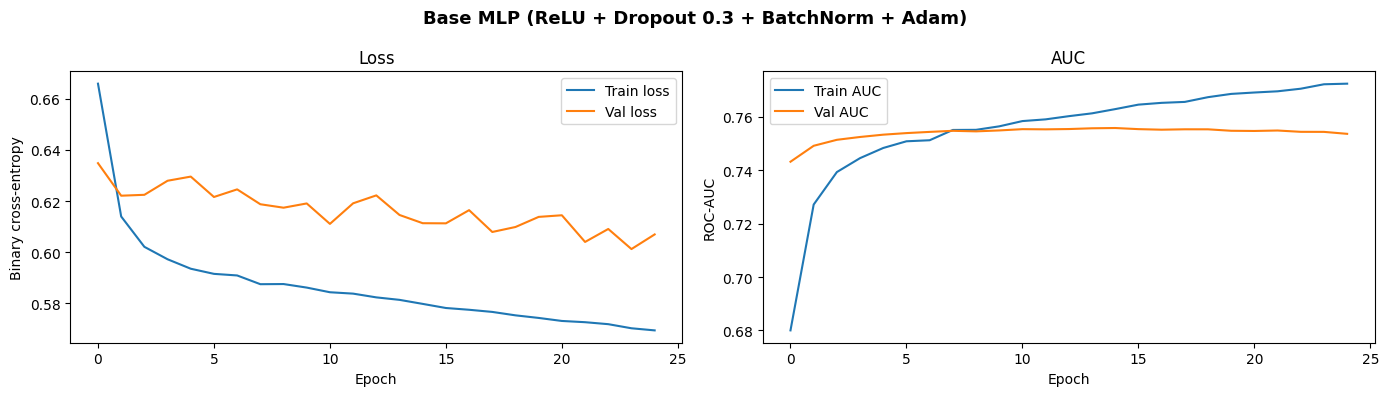

In [8]:
plot_training_curves(history_base, title="Base MLP (ReLU + Dropout 0.3 + BatchNorm + Adam)")

The key takeaway from these charts is that the model overfitted the training data. The distance between the Val and Train losses keep increasing. Moreover, on the Val data both the loss and AUC do not see many improvements along the epochs.

### 4.3 Evaluation — validation and test sets

In [9]:
metrics_base_val  = evaluate_keras_model(base_model, X_val_arr,  y_val_arr,  split_name="Val")
metrics_base_test = evaluate_keras_model(base_model, X_test_arr, y_test_arr, split_name="Test")


  Val — threshold = 0.3
  ROC-AUC : 0.7558
  PR-AUC  : 0.2368

                precision    recall  f1-score   support

No Default (0)       0.98      0.33      0.49     42402
   Default (1)       0.11      0.93      0.19      3724

      accuracy                           0.38     46126
     macro avg       0.54      0.63      0.34     46126
  weighted avg       0.91      0.38      0.47     46126


  Test — threshold = 0.3
  ROC-AUC : 0.7568
  PR-AUC  : 0.2416

                precision    recall  f1-score   support

No Default (0)       0.98      0.33      0.49     42402
   Default (1)       0.11      0.92      0.19      3724

      accuracy                           0.37     46126
     macro avg       0.54      0.62      0.34     46126
  weighted avg       0.91      0.37      0.46     46126



These results are extremely poor. Our model can easily get a 98% precision on "No Default" because the data is extremely unbalanced, but when it comes to "Defaults" it is terrible (11%). On the other hand, our model captures 93% of all "Defaults", but it does not capture the "No Defaults" (32%), meaning it is predicting "Default" more times than it should. We tecnically want a high recall, since we do not want to miss "Default" cases, but this model is not good despite doing this.

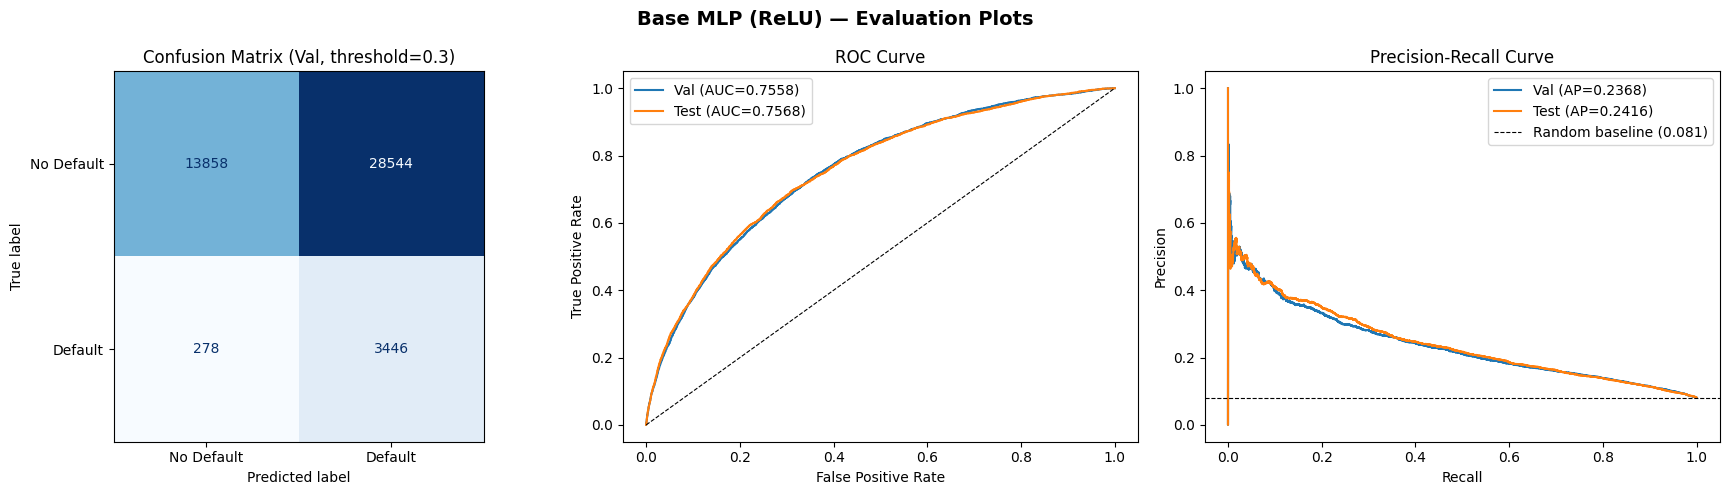

In [10]:
plot_evaluation_keras(base_model, X_val_arr, y_val_arr, X_test_arr, y_test_arr,
                      title_prefix="Base MLP (ReLU)")

## 5. Leaky ReLU MLP — Avoiding Dead Neurons

**The dead neuron problem with ReLU:**  
ReLU outputs exactly 0 for any negative pre-activation. Once a neuron's output is 0, the
gradient flowing through it is also 0. If this happens consistently across many training steps,
the neuron's weights stop updating entirely — the neuron is "dead" and contributes nothing
to the network for the rest of training.

This is especially likely with:
- High learning rates that push weights into the negative region.
- Features that are already zero or negative after scaling.
- Large dropout rates combined with ReLU.

**Leaky ReLU** fixes this by allowing a small, non-zero gradient for negative inputs:

$$
\text{LeakyReLU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{otherwise} \end{cases}
$$

where $\alpha$ is a small constant (typically 0.1 or 0.3). The negative slope ensures the
gradient is never exactly 0, so all neurons remain "alive" throughout training.

We use the **same architecture and hyperparameters** as the base MLP to isolate the effect
of the activation function.

In [11]:
def build_mlp_leaky_relu(n_features, hidden_units=(128, 64), dropout_rate=0.3,
                          use_batchnorm=True, learning_rate=0.001, alpha=0.1):
    """
    Leaky ReLU passes a small fraction (alpha) of negative inputs, preventing
    dead neurons while keeping the benefits of the ReLU family (no saturation
    for large positive inputs, sparse activation).

    Parameters
    ----------
    alpha : float — negative slope coefficient (default 0.1; 0.3 is also common)
    """
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential(name="MLP_LeakyReLU")
    model.add(layers.Input(shape=(n_features,)))

    for units in hidden_units:
        model.add(layers.Dense(units, use_bias=not use_batchnorm))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        #LeakyReLU is its own layer in Keras; alpha controls the negative slope
        model.add(layers.LeakyReLU(negative_slope=alpha))
        model.add(layers.Dropout(dropout_rate, seed=SEED))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model


leaky_model = build_mlp_leaky_relu(N_FEATURES, hidden_units=(128, 64), dropout_rate=0.3,
                                    use_batchnorm=True, learning_rate=0.001, alpha=0.1)
leaky_model.summary()

Model: "MLP_LeakyReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,489 (91.75 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
early_stop_leaky = EarlyStopping(
    monitor='val_auc', patience=10, mode='max',
    restore_best_weights=True, verbose=1
)

print("Training Leaky ReLU MLP (alpha=0.1, dropout=0.3, BatchNorm, Adam lr=0.001)...")
t0 = time.time()

history_leaky = leaky_model.fit(
    X_train_arr, y_train_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop_leaky],
    class_weight=CLASS_WEIGHT,   # same weights as base model for fair comparison
    verbose=1
)

train_time_leaky = time.time() - t0
print(f"\nTraining time: {train_time_leaky:.1f}s")

Training Leaky ReLU MLP (alpha=0.1, dropout=0.3, BatchNorm, Adam lr=0.001)...
Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - auc: 0.6932 - loss: 0.6486 - val_auc: 0.7449 - val_loss: 0.6171
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7310 - loss: 0.6093 - val_auc: 0.7501 - val_loss: 0.6168
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7424 - loss: 0.5989 - val_auc: 0.7523 - val_loss: 0.6209
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7459 - loss: 0.5961 - val_auc: 0.7533 - val_loss: 0.6159
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7486 - loss: 0.5935 - val_auc: 0.7539 - val_loss: 0.6205
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7513 - loss: 0.5912 - val_auc: 0.7544 - val_loss: 0.6164
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7527 - loss: 0.5897 - val_auc: 0.7548 - val_loss: 0.6145
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.7545 - loss: 0.5880 - val_

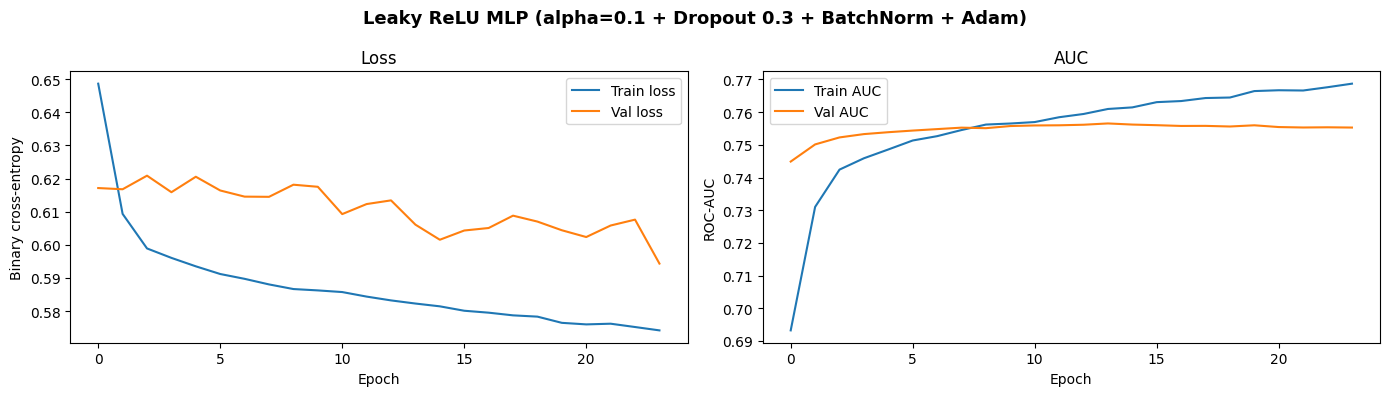

In [13]:
plot_training_curves(history_leaky, title="Leaky ReLU MLP (alpha=0.1 + Dropout 0.3 + BatchNorm + Adam)")

Again we are looking at an overfitted model.

In [14]:
metrics_leaky_val  = evaluate_keras_model(leaky_model, X_val_arr,  y_val_arr,  split_name="Val")
metrics_leaky_test = evaluate_keras_model(leaky_model, X_test_arr, y_test_arr, split_name="Test")


  Val — threshold = 0.3
  ROC-AUC : 0.7566
  PR-AUC  : 0.2366

                precision    recall  f1-score   support

No Default (0)       0.98      0.33      0.49     42402
   Default (1)       0.11      0.92      0.19      3724

      accuracy                           0.38     46126
     macro avg       0.54      0.63      0.34     46126
  weighted avg       0.91      0.38      0.47     46126


  Test — threshold = 0.3
  ROC-AUC : 0.7564
  PR-AUC  : 0.2393

                precision    recall  f1-score   support

No Default (0)       0.98      0.33      0.49     42402
   Default (1)       0.11      0.92      0.19      3724

      accuracy                           0.38     46126
     macro avg       0.54      0.62      0.34     46126
  weighted avg       0.91      0.38      0.47     46126



Our "No Default" class increased its f1-score by 2 pp, which now sits at 50%, which is still bad. The "Default" class stayed the same and this model is very similar to the ReLu one.

### 5.1 ReLU vs Leaky ReLU — side-by-side comparison

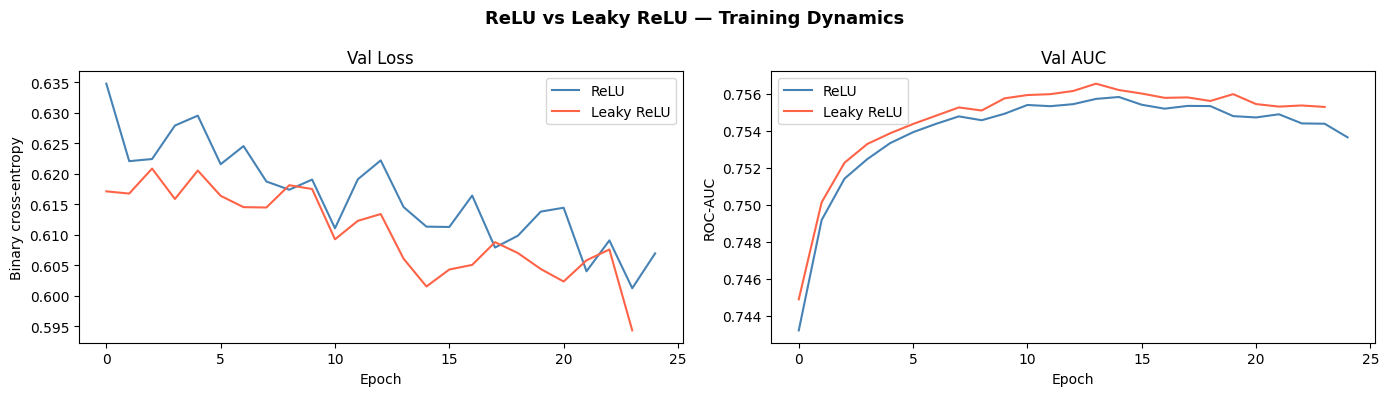

                 Model Val AUC Train time             Dead neurons
                  ReLU  0.7558      34.7s   Possible with large lr
Leaky ReLU (alpha=0.1)  0.7566      30.8s Prevented by alpha slope


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("ReLU vs Leaky ReLU — Training Dynamics", fontsize=13, fontweight='bold')

#find the AUC key dynamically (Keras may suffix duplicate metric names)
def _auc_key(h): return [k for k in h.history if 'auc' in k and 'val' not in k][0]

for history, label, color in [
    (history_base,  'ReLU',        'steelblue'),
    (history_leaky, 'Leaky ReLU',  'tomato'),
]:
    auc_k = _auc_key(history)
    axes[0].plot(history.history['val_loss'], label=label, color=color)
    axes[1].plot(history.history[f'val_{auc_k}'], label=label, color=color)

axes[0].set_title("Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()

axes[1].set_title("Val AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

#quick summary table
auc_relu   = roc_auc_score(y_val_arr, base_model.predict(X_val_arr, verbose=0).ravel())
auc_leaky  = roc_auc_score(y_val_arr, leaky_model.predict(X_val_arr, verbose=0).ravel())

comp = pd.DataFrame({
    "Model"       : ["ReLU", "Leaky ReLU (alpha=0.1)"],
    "Val AUC"     : [f"{auc_relu:.4f}", f"{auc_leaky:.4f}"],
    "Train time"  : [f"{train_time_base:.1f}s", f"{train_time_leaky:.1f}s"],
    "Dead neurons": ["Possible with large lr", "Prevented by alpha slope"],
})
print(comp.to_string(index=False))

Leaky ReLu registered a lower Val Loss than with the normal ReLu.

## 6. Hyperparameter Experiments

Systematic sweep over four axes:
1. **Dropout rate:** 0.2 / 0.3 / 0.4 / 0.5
2. **BatchNorm:** On / Off
3. **Layer sizes:** [128, 64] / [256, 128, 64] / [64, 32]
4. **Learning rate:** 0.001 / 0.0001

Each config is trained with early stopping (patience=10) to ensure fair comparison.
We use the best Leaky ReLU architecture (alpha=0.1) as the sweep base since it avoids
dead neurons and performed comparably or better than plain ReLU.

> **Runtime note:** 12 configs × up to 100 epochs on a T4 GPU ≈ 8–15 min total.

In [16]:
sweep_configs = [
    #dropout, use_batchnorm, hidden_units, lr,label
    (0.2,  True,  (128, 64),       0.001,  "drop=0.2 | BN | [128,64]  | lr=0.001"),
    (0.3,  True,  (128, 64),       0.001,  "drop=0.3 | BN | [128,64]  | lr=0.001  ← base"),
    (0.4,  True,  (128, 64),       0.001,  "drop=0.4 | BN | [128,64]  | lr=0.001"),
    (0.5,  True,  (128, 64),       0.001,  "drop=0.5 | BN | [128,64]  | lr=0.001"),
    (0.3,  False, (128, 64),       0.001,  "drop=0.3 | no BN | [128,64] | lr=0.001"),
    (0.3,  True,  (256, 128, 64),  0.001,  "drop=0.3 | BN | [256,128,64] | lr=0.001"),
    (0.3,  True,  (64, 32),        0.001,  "drop=0.3 | BN | [64,32]   | lr=0.001"),
    (0.3,  True,  (128, 64),       0.0001, "drop=0.3 | BN | [128,64]  | lr=0.0001"),
    (0.2,  True,  (256, 128, 64),  0.001,  "drop=0.2 | BN | [256,128,64] | lr=0.001"),
    (0.4,  False, (128, 64),       0.001,  "drop=0.4 | no BN | [128,64] | lr=0.001"),
    (0.3,  True,  (256, 128, 64),  0.0001, "drop=0.3 | BN | [256,128,64] | lr=0.0001"),
    (0.2,  True,  (128, 64),       0.0001, "drop=0.2 | BN | [128,64]  | lr=0.0001"),
]

sweep_results = []

for dropout, use_bn, units, lr, label in sweep_configs:
    print(f"\n[CONFIG] {label}")

    model = build_mlp_leaky_relu(
        N_FEATURES, hidden_units=units, dropout_rate=dropout,
        use_batchnorm=use_bn, learning_rate=lr, alpha=0.1
    )

    es = EarlyStopping(monitor='val_auc', patience=10, mode='max',
                       restore_best_weights=True, verbose=0)

    t0 = time.time()
    hist = model.fit(
        X_train_arr, y_train_arr,
        validation_data=(X_val_arr, y_val_arr),
        epochs=100,
        batch_size=1024,
        callbacks=[es],
        verbose=0
    )
    elapsed = time.time() - t0

    auc_key = [k for k in hist.history if 'auc' in k and 'val' not in k][0]
    best_val_auc  = max(hist.history[f'val_{auc_key}'])
    best_val_loss = min(hist.history['val_loss'])
    n_params      = model.count_params()
    epochs_run    = len(hist.history['loss'])

    sweep_results.append({
        "Config"         : label,
        "Dropout"        : dropout,
        "BatchNorm"      : use_bn,
        "Hidden units"   : str(units),
        "LR"             : lr,
        "Best val AUC"   : round(best_val_auc, 4),
        "Best val loss"  : round(best_val_loss, 4),
        "Epochs run"     : epochs_run,
        "Params"         : n_params,
        "Train time (s)" : round(elapsed, 1),
    })
    print(f"  Best val AUC: {best_val_auc:.4f}  |  epochs: {epochs_run}  |  time: {elapsed:.1f}s")

sweep_df = pd.DataFrame(sweep_results).sort_values("Best val AUC", ascending=False).reset_index(drop=True)
print("\n=== Hyperparameter Sweep Results (sorted by val AUC) ===")
display(sweep_df)


[CONFIG] drop=0.2 | BN | [128,64]  | lr=0.001
  Best val AUC: 0.7550  |  epochs: 20  |  time: 28.6s

[CONFIG] drop=0.3 | BN | [128,64]  | lr=0.001  ← base
  Best val AUC: 0.7566  |  epochs: 39  |  time: 65.9s

[CONFIG] drop=0.4 | BN | [128,64]  | lr=0.001
  Best val AUC: 0.7563  |  epochs: 30  |  time: 36.9s

[CONFIG] drop=0.5 | BN | [128,64]  | lr=0.001
  Best val AUC: 0.7570  |  epochs: 50  |  time: 53.9s

[CONFIG] drop=0.3 | no BN | [128,64] | lr=0.001
  Best val AUC: 0.7558  |  epochs: 25  |  time: 31.3s

[CONFIG] drop=0.3 | BN | [256,128,64] | lr=0.001
  Best val AUC: 0.7563  |  epochs: 25  |  time: 38.2s

[CONFIG] drop=0.3 | BN | [64,32]   | lr=0.001
  Best val AUC: 0.7564  |  epochs: 43  |  time: 47.7s

[CONFIG] drop=0.3 | BN | [128,64]  | lr=0.0001
  Best val AUC: 0.7575  |  epochs: 100  |  time: 100.1s

[CONFIG] drop=0.2 | BN | [256,128,64] | lr=0.001
  Best val AUC: 0.7542  |  epochs: 22  |  time: 34.2s

[CONFIG] drop=0.4 | no BN | [128,64] | lr=0.001
  Best val AUC: 0.7558 

,Config,Dropout,BatchNorm,Hidden units,LR,Best val AUC,Best val loss,Epochs run,Params,Train time (s)
0,"drop=0.3 | BN | [128,64] | lr=0.0001",0.3,True,"(128, 64)",0.0001,0.7575,0.2475,100,23489,100.1
1,"drop=0.3 | BN | [256,128,64] | lr=0.0001",0.3,True,"(256, 128, 64)",0.0001,0.7573,0.2476,99,71745,110.3
2,"drop=0.5 | BN | [128,64] | lr=0.001",0.5,True,"(128, 64)",0.0010,0.7570,0.2477,50,23489,53.9
3,"drop=0.3 | BN | [128,64] | lr=0.001 ← base",0.3,True,"(128, 64)",0.0010,0.7566,0.2477,39,23489,65.9
4,"drop=0.2 | BN | [128,64] | lr=0.0001",0.2,True,"(128, 64)",0.0001,0.7564,0.2476,100,23489,106.6
5,"drop=0.3 | BN | [64,32] | lr=0.001",0.3,True,"(64, 32)",0.0010,0.7564,0.2470,43,9697,47.7
6,"drop=0.3 | BN | [256,128,64] | lr=0.001",0.3,True,"(256, 128, 64)",0.0010,0.7563,0.2473,25,71745,38.2
7,"drop=0.4 | BN | [128,64] | lr=0.001",0.4,True,"(128, 64)",0.0010,0.7563,0.2479,30,23489,36.9
8,"drop=0.4 | no BN | [128,64] | lr=0.001",0.4,False,"(128, 64)",0.0010,0.7558,0.2473,48,22913,51.9
9,"drop=0.3 | no BN | [128,64] | lr=0.001",0.3,False,"(128, 64)",0.0010,0.7558,0.2477,25,22913,31.3


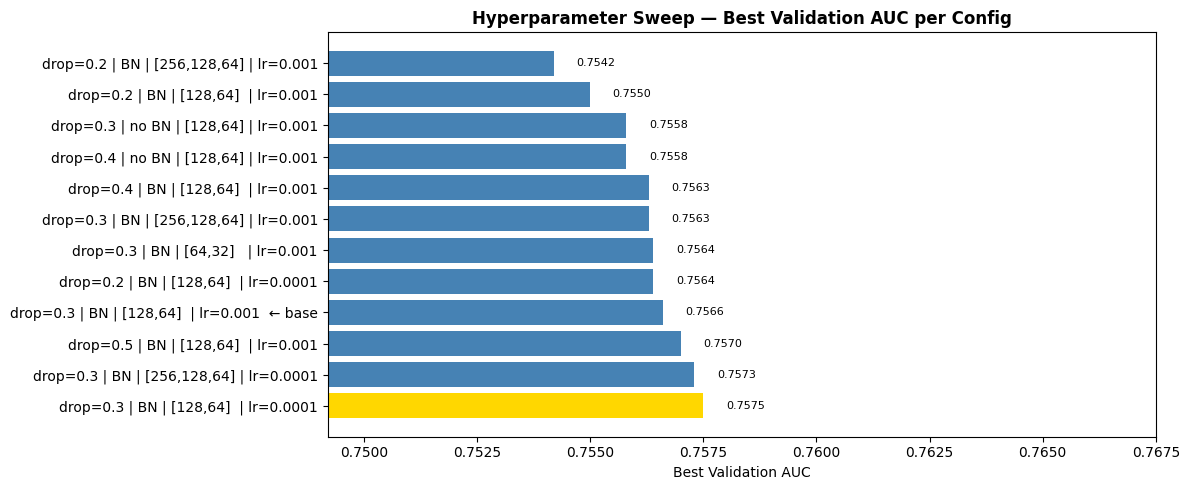


Best config: drop=0.3 | BN | [128,64]  | lr=0.0001
Val AUC: 0.7575


In [17]:
#visual summary of the sweep
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(sweep_df))]
bars = ax.barh(sweep_df["Config"], sweep_df["Best val AUC"], color=colors)
ax.set_xlabel("Best Validation AUC")
ax.set_title("Hyperparameter Sweep — Best Validation AUC per Config", fontweight='bold')

#annotate each bar with its AUC value
for bar, val in zip(bars, sweep_df["Best val AUC"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', fontsize=8)

ax.set_xlim(sweep_df["Best val AUC"].min() - 0.005, sweep_df["Best val AUC"].max() + 0.01)
plt.tight_layout()
plt.show()

best_config = sweep_df.iloc[0]
print(f"\nBest config: {best_config['Config']}")
print(f"Val AUC: {best_config['Best val AUC']:.4f}")

## 7. Regularisation Ablation Study — RQ1 Centrepiece

This section directly addresses **RQ1**: *How do different regularisation strategies affect
predictive performance and model complexity?*

We train five variants of the same architecture (best config from Section 6), toggling
regularisation techniques on and off one at a time:

| Variant | Dropout | BatchNorm | Early stopping | Notes |
|---|---|---|---|---|
| None | ✗ | ✗ | ✗ (100 epochs fixed) | Unregularised — expected to overfit |
| Dropout only | ✓ | ✗ | ✗ (100 epochs fixed) | L2-equivalent effect via stochastic masking |
| BatchNorm only | ✗ | ✓ | ✗ (100 epochs fixed) | Mild regulariser + stable training |
| Early stopping only | ✗ | ✗ | ✓ | Complexity control via training duration |
| All three | ✓ | ✓ | ✓ | Full regularisation — expected best val AUC |

In [18]:
#use the best architecture from the sweep
BEST_UNITS   = eval(best_config["Hidden units"])
BEST_DROPOUT = best_config["Dropout"]
BEST_LR      = best_config["LR"]

print(f"Ablation architecture: units={BEST_UNITS}, dropout={BEST_DROPOUT}, lr={BEST_LR}")

ablation_configs = [
    # label,                       dropout,       use_bn, use_early_stop
    ("No regularisation",          0.0,           False,  False),
    ("Dropout only",               BEST_DROPOUT,  False,  False),
    ("BatchNorm only",             0.0,           True,   False),
    ("Early stopping only",        0.0,           False,  True),
    ("All three (Dropout+BN+ES)",  BEST_DROPOUT,  True,   True),
]

ablation_results = []
ablation_histories = {}

for label, dropout, use_bn, use_es in ablation_configs:
    print(f"\n[ABLATION] {label}")

    model = build_mlp_leaky_relu(
        N_FEATURES, hidden_units=BEST_UNITS,
        dropout_rate=dropout, use_batchnorm=use_bn,
        learning_rate=BEST_LR, alpha=0.1
    )

    callbacks = []
    if use_es:
        callbacks.append(EarlyStopping(
            monitor='val_auc', patience=10, mode='max',
            restore_best_weights=True, verbose=0
        ))

    t0 = time.time()
    hist = model.fit(
        X_train_arr, y_train_arr,
        validation_data=(X_val_arr, y_val_arr),
        epochs=100,
        batch_size=1024,
        callbacks=callbacks,
        verbose=0
    )
    elapsed = time.time() - t0

    auc_key     = [k for k in hist.history if 'auc' in k and 'val' not in k][0]
    train_auc   = max(hist.history[auc_key])
    val_auc     = max(hist.history[f'val_{auc_key}'])
    train_loss  = min(hist.history['loss'])
    val_loss    = min(hist.history['val_loss'])
    epochs_run  = len(hist.history['loss'])
    overfit_gap = round(train_auc - val_auc, 4)

    ablation_results.append({
        "Variant"           : label,
        "Dropout"           : dropout,
        "BatchNorm"         : use_bn,
        "Early stopping"    : use_es,
        "Best train AUC"    : round(train_auc, 4),
        "Best val AUC"      : round(val_auc, 4),
        "Train-Val gap"     : overfit_gap,
        "Best val loss"     : round(val_loss, 4),
        "Epochs run"        : epochs_run,
        "Train time (s)"    : round(elapsed, 1),
    })
    ablation_histories[label] = hist

    print(f"  Train AUC: {train_auc:.4f}  |  Val AUC: {val_auc:.4f}  "
          f"|  Gap: {overfit_gap:.4f}  |  Epochs: {epochs_run}")

ablation_df = pd.DataFrame(ablation_results)
print("\n=== Regularisation Ablation Study Results ===")
display(ablation_df)

Ablation architecture: units=(128, 64), dropout=0.3, lr=0.0001

[ABLATION] No regularisation
  Train AUC: 0.7996  |  Val AUC: 0.7512  |  Gap: 0.0483  |  Epochs: 100

[ABLATION] Dropout only
  Train AUC: 0.7584  |  Val AUC: 0.7549  |  Gap: 0.0035  |  Epochs: 100

[ABLATION] BatchNorm only
  Train AUC: 0.8234  |  Val AUC: 0.7477  |  Gap: 0.0757  |  Epochs: 100

[ABLATION] Early stopping only
  Train AUC: 0.7763  |  Val AUC: 0.7523  |  Gap: 0.0240  |  Epochs: 47

[ABLATION] All three (Dropout+BN+ES)
  Train AUC: 0.7581  |  Val AUC: 0.7564  |  Gap: 0.0017  |  Epochs: 100

=== Regularisation Ablation Study Results ===


,Variant,Dropout,BatchNorm,Early stopping,Best train AUC,Best val AUC,Train-Val gap,Best val loss,Epochs run,Train time (s)
0,No regularisation,0.0,False,False,0.7996,0.7512,0.0483,0.2485,100,90.6
1,Dropout only,0.3,False,False,0.7584,0.7549,0.0035,0.2476,100,101.8
2,BatchNorm only,0.0,True,False,0.8234,0.7477,0.0757,0.2497,100,99.6
3,Early stopping only,0.0,False,True,0.7763,0.7523,0.0240,0.2484,47,48.6
4,All three (Dropout+BN+ES),0.3,True,True,0.7581,0.7564,0.0017,0.2480,100,103.2


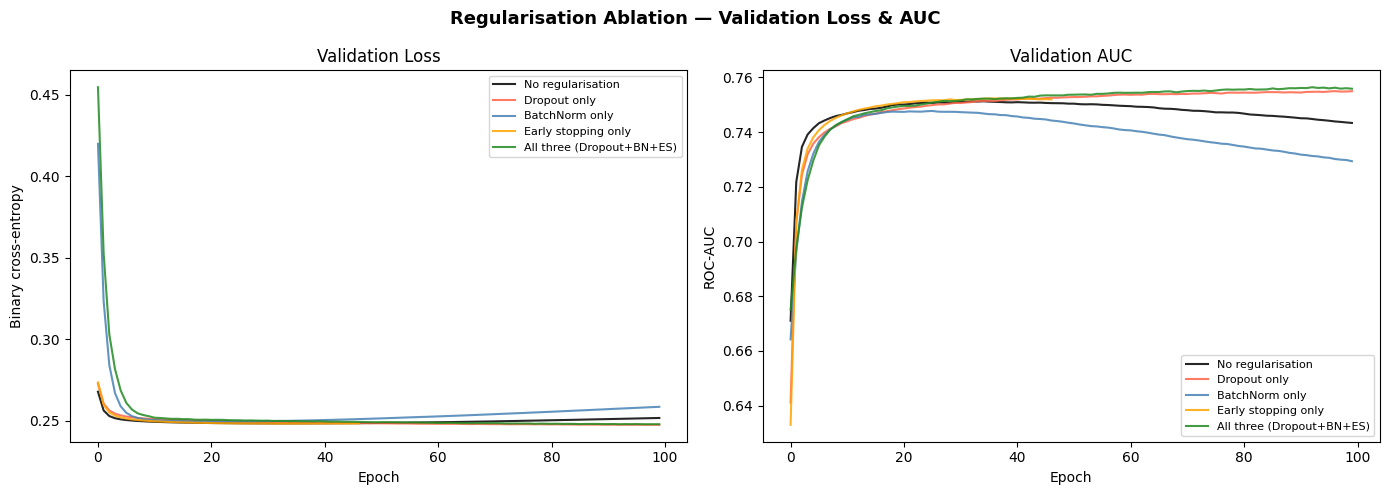

In [19]:
#Training curves for all 5 ablation variants
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Regularisation Ablation — Validation Loss & AUC", fontsize=13, fontweight='bold')

palette = ['black', 'tomato', 'steelblue', 'orange', 'forestgreen']

for (label, _, _, _), color in zip(ablation_configs, palette):
    hist = ablation_histories[label]
    auc_key = [k for k in hist.history if 'auc' in k and 'val' not in k][0]

    axes[0].plot(hist.history['val_loss'],           label=label, color=color, alpha=0.85)
    axes[1].plot(hist.history[f'val_{auc_key}'],     label=label, color=color, alpha=0.85)

for ax, title, ylabel in [
    (axes[0], "Validation Loss", "Binary cross-entropy"),
    (axes[1], "Validation AUC",  "ROC-AUC"),
]:
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

From these graphs we can conclude that only the models "Dropout only" and "All three" are the ones where the loss is reducing after around 10 epochs. More importantly, the model with "All three" generated the best Val AUC, Val Loss and Train-Val gap, which means it is the one overfitting the least while still having good predictive power.

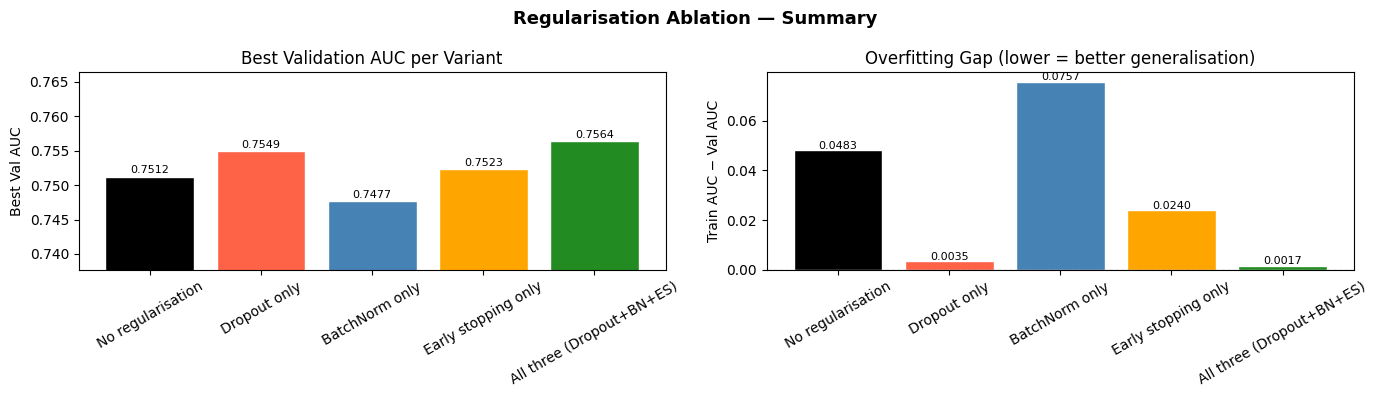

In [20]:
#bar chart: best val AUC per variant
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Regularisation Ablation — Summary", fontsize=13, fontweight='bold')

palette_ablation = ['black', 'tomato', 'steelblue', 'orange', 'forestgreen']

#Val AUC
bars = axes[0].bar(ablation_df["Variant"], ablation_df["Best val AUC"],
                   color=palette_ablation, edgecolor='white')
axes[0].set_ylabel("Best Val AUC")
axes[0].set_title("Best Validation AUC per Variant")
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(ablation_df["Best val AUC"].min() - 0.01, ablation_df["Best val AUC"].max() + 0.01)
for bar, val in zip(bars, ablation_df["Best val AUC"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{val:.4f}", ha='center', fontsize=8)

#Train-Val gap (overfitting proxy)
bars2 = axes[1].bar(ablation_df["Variant"], ablation_df["Train-Val gap"],
                    color=palette_ablation, edgecolor='white')
axes[1].set_ylabel("Train AUC − Val AUC")
axes[1].set_title("Overfitting Gap (lower = better generalisation)")
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, ablation_df["Train-Val gap"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{val:.4f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. SMOTE vs Non-SMOTE Comparison

We take the **best MLP configuration** identified from the ablation study (all three
regularisers active) and train it on both:
- `X_train` / `y_train` — original imbalanced set (~8% default rate)
- `X_train_smote` / `y_train_smote` — SMOTE-resampled (50/50 balance)

The goal is to understand how resampling shifts the **precision/recall trade-off**:
- SMOTE inflates the minority class, which typically improves recall on defaulters at the cost
  of some precision.
- The original set retains the natural class distribution; the model may prefer predicting
  non-default since it is by far the majority class.

In [21]:
def train_best_mlp(X_train_data, y_train_data, label="original"):
    """
    Train the best MLP config (all three regularisers) on a given training set.
    Returns (model, history, training_time).
    """
    model = build_mlp_leaky_relu(
        N_FEATURES,
        hidden_units=BEST_UNITS,
        dropout_rate=BEST_DROPOUT,
        use_batchnorm=True,
        learning_rate=BEST_LR,
        alpha=0.1
    )

    es = EarlyStopping(monitor='val_auc', patience=10, mode='max',
                       restore_best_weights=True, verbose=0)

    print(f"Training best MLP on {label} set (n={len(X_train_data):,})...")
    t0 = time.time()
    hist = model.fit(
        X_train_data, y_train_data,
        validation_data=(X_val_arr, y_val_arr),
        epochs=100,
        batch_size=1024,
        callbacks=[es],
        verbose=0
    )
    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s")
    return model, hist, elapsed


best_model_orig,  hist_orig,  time_orig  = train_best_mlp(X_train_arr,       y_train_arr,       label="original")
best_model_smote, hist_smote, time_smote = train_best_mlp(X_train_smote_arr, y_train_smote_arr, label="SMOTE")

Training best MLP on original set (n=215,253)...
  Done in 101.0s
Training best MLP on SMOTE set (n=395,752)...
  Done in 31.7s


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

def smote_comparison_metrics(model, X, y, label, threshold=0.3):
    """Return a dict of metrics for the SMOTE comparison table."""
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model"         : label,
        "Split"         : "Val" if X is X_val_arr else "Test",
        "ROC-AUC"       : round(roc_auc_score(y, y_prob), 4),
        "PR-AUC"        : round(average_precision_score(y, y_prob), 4),
        "Precision (1)" : round(precision_score(y, y_pred, pos_label=1, zero_division=0), 4),
        "Recall (1)"    : round(recall_score(y, y_pred, pos_label=1), 4),
        "F1 (1)"        : round(f1_score(y, y_pred, pos_label=1), 4),
    }

rows = []
for model, label in [(best_model_orig, "Original"), (best_model_smote, "SMOTE")]:
    for X, y, split in [(X_val_arr, y_val_arr, "Val"), (X_test_arr, y_test_arr, "Test")]:
        r = smote_comparison_metrics(model, X, y, label)
        r["Split"] = split
        rows.append(r)

smote_df = pd.DataFrame(rows)
print("=== SMOTE vs Original — Precision/Recall Impact ===")
display(smote_df)

=== SMOTE vs Original — Precision/Recall Impact ===


,Model,Split,ROC-AUC,PR-AUC,Precision (1),Recall (1),F1 (1)
0,Original,Val,0.7567,0.2385,0.3511,0.1643,0.2239
1,Original,Test,0.7565,0.2413,0.3596,0.1719,0.2326
2,SMOTE,Val,0.7392,0.2150,0.1168,0.8676,0.2059
3,SMOTE,Test,0.7419,0.2178,0.1163,0.8687,0.2052


SMOTE data created some models with high recall, this is because SMOTE is known to make models overestimate the minority class, this can be seen in the extremely low precision score.

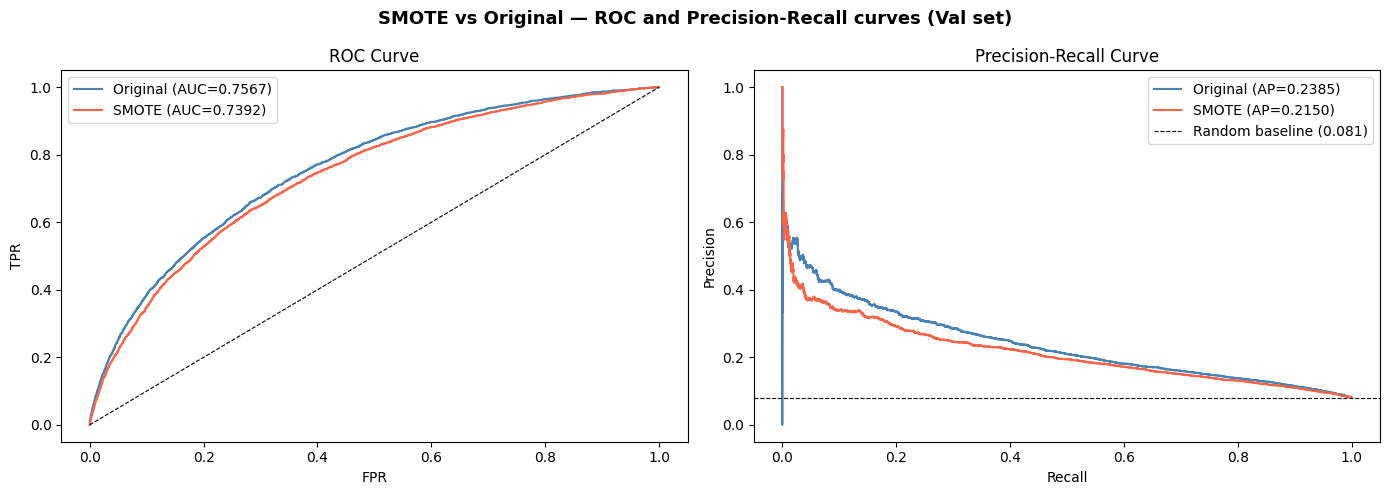

In [23]:
#PR curve comparison (val set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SMOTE vs Original — ROC and Precision-Recall curves (Val set)",
             fontsize=13, fontweight='bold')

for model, label, color in [
    (best_model_orig,  "Original", 'steelblue'),
    (best_model_smote, "SMOTE",    'tomato'),
]:
    y_prob = model.predict(X_val_arr, verbose=0).ravel()

    fpr, tpr, _ = roc_curve(y_val_arr, y_prob)
    auc = roc_auc_score(y_val_arr, y_prob)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})", color=color)

    prec, rec, _ = precision_recall_curve(y_val_arr, y_prob)
    ap = average_precision_score(y_val_arr, y_prob)
    axes[1].plot(rec, prec, label=f"{label} (AP={ap:.4f})", color=color)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend()

baseline_rate = y_val_arr.mean()
axes[1].axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8,
                label=f"Random baseline ({baseline_rate:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Final MLP — Default DNN Configuration

We train one final MLP following the **published default DNN configuration** (Géron, 2022,
*Hands-On Machine Learning*, Table 11-2). This configuration is explicitly designed for
self-normalising deep networks and differs substantially from the dropout-based approach above:

| Hyperparameter | Value | Rationale |
|---|---|---|
| Kernel initialiser | LeCun (Normal) | Ensures variance ≈ 1 at each layer — precondition for SELU self-normalisation |
| Activation | SELU | Scaled Exponential Linear Unit: pushes activations towards zero mean / unit variance automatically |
| Normalisation | None (self-normalisation) | SELU + LeCun init provides normalisation without BatchNorm |
| Regularisation | Early stopping | Complexity control via training duration |
| Optimizer | Nadam | Nesterov momentum + Adam adaptive rates; often converges faster than plain Adam |
| LR schedule | Performance (ReduceLROnPlateau) | Halves LR when val_loss stagnates — coarse-to-fine optimisation |

> **SELU caveat:** SELU requires the inputs to each neuron to be i.i.d. with zero mean and
> unit variance, the network weights to be initialised with LeCun Normal, and the network to
> be fully connected (no skip connections, no BatchNorm). All three conditions are met here.

In [24]:
def build_mlp_default_dnn(n_features, hidden_units=(128, 64), learning_rate=0.001):
    """
    Build the Default DNN configuration from Géron (2022), Table 11-2.

    Key design choices:
    - LeCun Normal initialiser: keeps variance stable layer-to-layer (required for SELU).
    - SELU activation: self-normalising which pushes layer outputs towards (mean=0, var=1)
      without explicit BatchNorm, reducing the number of hyperparameters.
    - No Dropout or BatchNorm: SELU handles normalisation; BatchNorm would undo SELU's
      self-normalising property. Dropout with SELU requires AlphaDropout to preserve
      the mean/variance, which is omitted here to stay faithful to the default config.
    - Nadam optimizer: Adam with Nesterov momentum, often faster than vanilla Adam.
    - Early stopping: the only regulariser which limits effective model complexity.
    - ReduceLROnPlateau: performance-based schedule which halves LR when val_loss plateaus.
    """
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    lecun_init = keras.initializers.LecunNormal(seed=SEED)

    model = keras.Sequential(name="MLP_Default_DNN")
    model.add(layers.Input(shape=(n_features,)))

    for units in hidden_units:
        model.add(layers.Dense(
            units,
            activation='selu',
            kernel_initializer=lecun_init
        ))
        #no BatchNorm — SELU self-normalises
        #no Dropout — would need AlphaDropout to preserve SELU's statistics

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model


dnn_model = build_mlp_default_dnn(N_FEATURES, hidden_units=BEST_UNITS, learning_rate=0.001)
dnn_model.summary()

Model: "MLP_Default_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,913 (89.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#allbacks
#Early stopping: stops when val_auc has not improved for 10 epochs
early_stop_dnn = EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

#Performance scheduling (ReduceLROnPlateau): halves LR when val_loss does not
#improve for 5 epochs — coarse optimisation first, then fine-tuning
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("Training Default DNN (SELU + LeCun init + Nadam + ReduceLROnPlateau + EarlyStopping)...")
t0 = time.time()

history_dnn = dnn_model.fit(
    X_train_arr, y_train_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop_dnn, reduce_lr],
    verbose=1
)

train_time_dnn = time.time() - t0
print(f"\nTraining time: {train_time_dnn:.1f}s")

Training Default DNN (SELU + LeCun init + Nadam + ReduceLROnPlateau + EarlyStopping)...
Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - auc: 0.7165 - loss: 0.2645 - val_auc: 0.7397 - val_loss: 0.2521 - learning_rate: 0.0010
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7423 - loss: 0.2508 - val_auc: 0.7435 - val_loss: 0.2510 - learning_rate: 0.0010
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7470 - loss: 0.2494 - val_auc: 0.7458 - val_loss: 0.2504 - learning_rate: 0.0010
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7505 - loss: 0.2483 - val_auc: 0.7474 - val_loss: 0.2500 - learning_rate: 0.0010
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7533 - loss: 0.2474 - val_auc: 0.7483 - val_loss: 0.2497 - learning_rate: 0.0010
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7554 - loss: 0.2467 - val_auc: 0.7491 - val_loss: 0.2495 - learning_rate: 0.0010
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

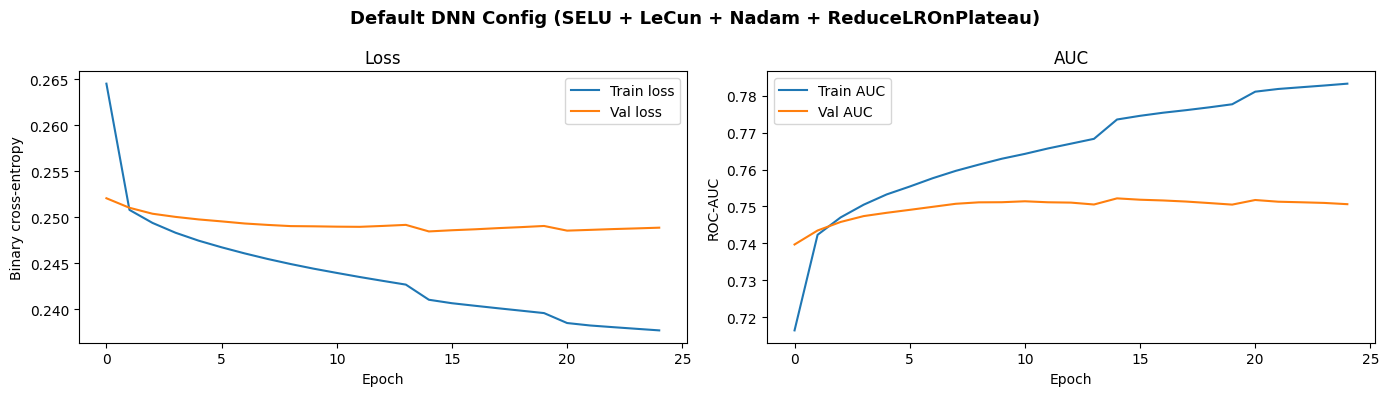

In [26]:
plot_training_curves(history_dnn,
                     title="Default DNN Config (SELU + LeCun + Nadam + ReduceLROnPlateau)")

In [27]:
metrics_dnn_val  = evaluate_keras_model(dnn_model, X_val_arr,  y_val_arr,  split_name="Val")
metrics_dnn_test = evaluate_keras_model(dnn_model, X_test_arr, y_test_arr, split_name="Test")


  Val — threshold = 0.3
  ROC-AUC : 0.7523
  PR-AUC  : 0.2368

                precision    recall  f1-score   support

No Default (0)       0.93      0.97      0.95     42402
   Default (1)       0.35      0.17      0.22      3724

      accuracy                           0.91     46126
     macro avg       0.64      0.57      0.59     46126
  weighted avg       0.88      0.91      0.89     46126


  Test — threshold = 0.3
  ROC-AUC : 0.7525
  PR-AUC  : 0.2359

                precision    recall  f1-score   support

No Default (0)       0.93      0.97      0.95     42402
   Default (1)       0.36      0.18      0.24      3724

      accuracy                           0.91     46126
     macro avg       0.65      0.58      0.60     46126
  weighted avg       0.89      0.91      0.89     46126



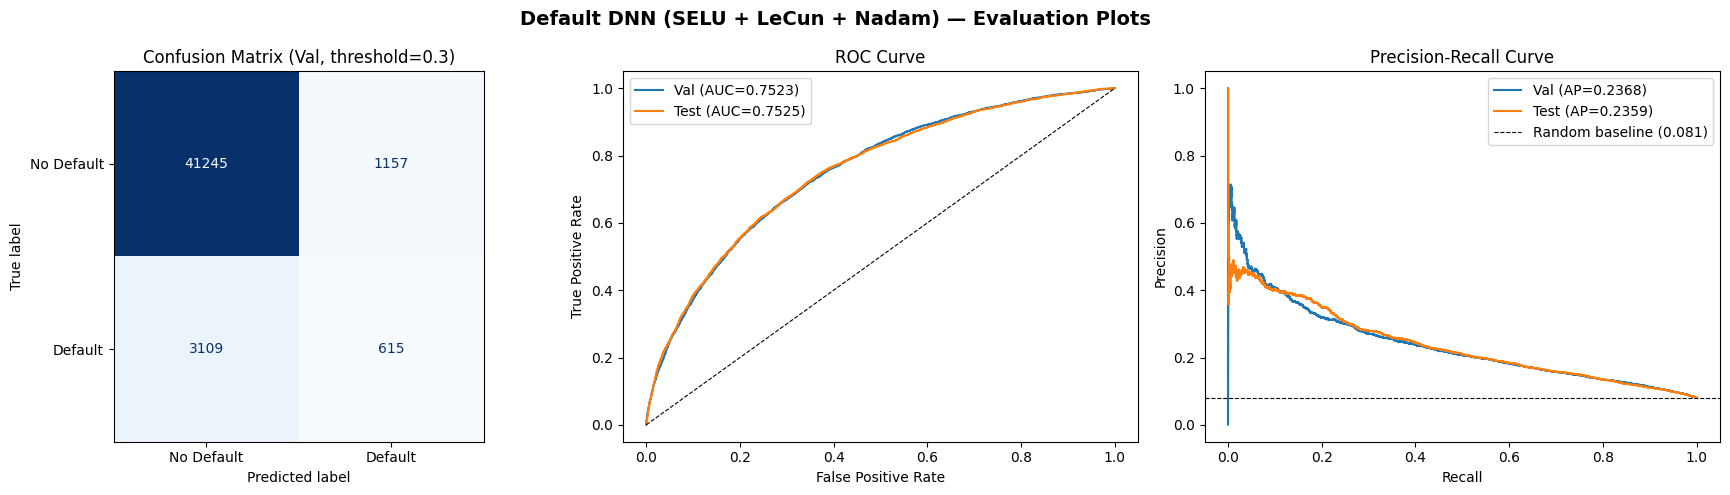

In [28]:
plot_evaluation_keras(dnn_model, X_val_arr, y_val_arr, X_test_arr, y_test_arr,
                      title_prefix="Default DNN (SELU + LeCun + Nadam)")

Despite this model overfitting the data, we came up with a 95% f1-score for "No Default", which is one of the best from all our models. Of course, the "Default" f1-score is very low, with a even lower recall, which is unnaceptable as we are trying to capture all "Default" cases.

## 10. Consolidated Model Comparison

All MLP variants evaluated on the **validation set** in one table, sorted by AUC.

In [29]:
def quick_val_metrics(model, name):
    y_prob = model.predict(X_val_arr, verbose=0).ravel()
    y_pred = (y_prob >= 0.3).astype(int)
    return {
        "Model"         : name,
        "Val ROC-AUC"   : round(roc_auc_score(y_val_arr, y_prob), 4),
        "Val PR-AUC"    : round(average_precision_score(y_val_arr, y_prob), 4),
        "Precision (1)" : round(precision_score(y_val_arr, y_pred, pos_label=1, zero_division=0), 4),
        "Recall (1)"    : round(recall_score(y_val_arr, y_pred, pos_label=1), 4),
        "F1 (1)"        : round(f1_score(y_val_arr, y_pred, pos_label=1), 4),
    }

summary_rows = [
    quick_val_metrics(base_model,        "Base MLP (ReLU)"),
    quick_val_metrics(leaky_model,       "Base MLP (Leaky ReLU)"),
    quick_val_metrics(best_model_orig,   "Best config — Original data"),
    quick_val_metrics(best_model_smote,  "Best config — SMOTE data"),
    quick_val_metrics(dnn_model,         "Default DNN (SELU + LeCun + Nadam)"),
]

summary_df = pd.DataFrame(summary_rows).sort_values("Val ROC-AUC", ascending=False).reset_index(drop=True)
print("=== MLP Variant Summary (Val set, sorted by AUC) ===")
display(summary_df)

=== MLP Variant Summary (Val set, sorted by AUC) ===


,Model,Val ROC-AUC,Val PR-AUC,Precision (1),Recall (1),F1 (1)
0,Best config — Original data,0.7567,0.2385,0.3511,0.1643,0.2239
1,Base MLP (Leaky ReLU),0.7566,0.2366,0.1077,0.9213,0.1928
2,Base MLP (ReLU),0.7558,0.2368,0.1077,0.9253,0.1930
3,Default DNN (SELU + LeCun + Nadam),0.7523,0.2368,0.3471,0.1651,0.2238
4,Best config — SMOTE data,0.7392,0.2150,0.1168,0.8676,0.2059


## 11. Save Best Model and Results

In [30]:
#identify and save the best model (highest val AUC)
best_model_name = summary_df.iloc[0]["Model"]
best_val_auc    = summary_df.iloc[0]["Val ROC-AUC"]
print(f"Best model: {best_model_name}  |  Val AUC: {best_val_auc:.4f}")

model_map = {
    "Base MLP (ReLU)"                    : base_model,
    "Base MLP (Leaky ReLU)"              : leaky_model,
    "Best config — Original data"        : best_model_orig,
    "Best config — SMOTE data"           : best_model_smote,
    "Default DNN (SELU + LeCun + Nadam)" : dnn_model,
}

best_mlp = model_map[best_model_name]

# save in Keras native format
best_mlp.save(f"{MODEL_DIR}/mlp_best.keras")
print(f"Saved best MLP to {MODEL_DIR}/mlp_best.keras")

# save the default DNN config model separately (distinct architecture)
dnn_model.save(f"{MODEL_DIR}/mlp_default_dnn.keras")
print(f"Saved default DNN config to {MODEL_DIR}/mlp_default_dnn.keras")

# save the ablation table and sweep table
ablation_df.to_csv(f"{MODEL_DIR}/mlp_ablation_results.csv", index=False)
sweep_df.to_csv(f"{MODEL_DIR}/mlp_sweep_results.csv",    index=False)
smote_df.to_csv(f"{MODEL_DIR}/mlp_smote_comparison.csv", index=False)
summary_df.to_csv(f"{MODEL_DIR}/mlp_summary.csv",        index=False)

print("\nAll result tables saved.")

Best model: Best config — Original data  |  Val AUC: 0.7567
Saved best MLP to /content/drive/MyDrive/MLDL/loan-default-project/03_models/mlp_best.keras
Saved default DNN config to /content/drive/MyDrive/MLDL/loan-default-project/03_models/mlp_default_dnn.keras

All result tables saved.


## 12. Final Test-Set Evaluation of Best MLP

The test set is touched **only once**. Do not re-tune any hyperparameters after seeing these results.

=== Final Test-Set Evaluation: Best config — Original data ===

  Test — threshold = 0.3
  ROC-AUC : 0.7565
  PR-AUC  : 0.2413

                precision    recall  f1-score   support

No Default (0)       0.93      0.97      0.95     42402
   Default (1)       0.36      0.17      0.23      3724

      accuracy                           0.91     46126
     macro avg       0.65      0.57      0.59     46126
  weighted avg       0.88      0.91      0.89     46126



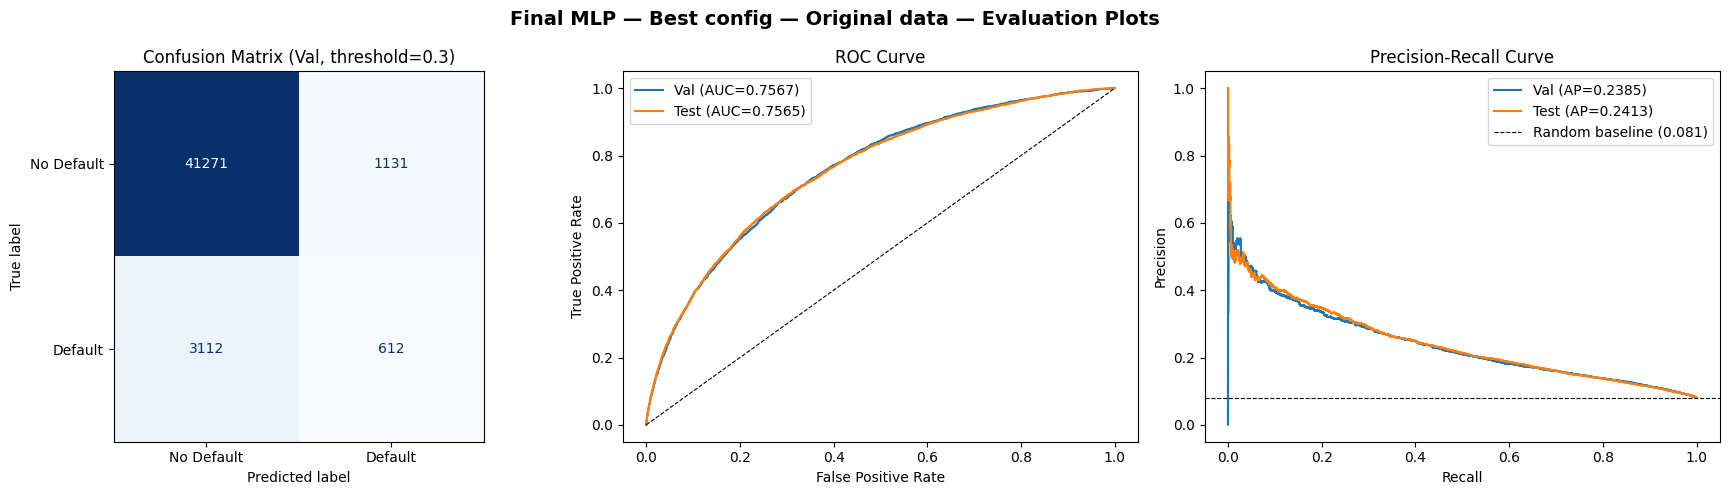


✓ Test ROC-AUC : 0.7565
✓ Test PR-AUC  : 0.2413


In [31]:
print(f"=== Final Test-Set Evaluation: {best_model_name} ===")
metrics_final = evaluate_keras_model(best_mlp, X_test_arr, y_test_arr, split_name="Test")

plot_evaluation_keras(best_mlp, X_val_arr, y_val_arr, X_test_arr, y_test_arr,
                      title_prefix=f"Final MLP — {best_model_name}")

print(f"\n\u2713 Test ROC-AUC : {metrics_final['roc_auc']:.4f}")
print(f"\u2713 Test PR-AUC  : {metrics_final['pr_auc']:.4f}")

**Conclusion**

Our best model in terms of Val AUC is the one with Dropout = 0.5, BatchNorm, Early Stopping with 1 layer with 128 nodes, another with 64 and the output node.

Still this model has low recall, which will means that we are horrible at finding who is going to default. Unbalanced data is extremely hard to predict with MLP models.

## 13. PCA Data — Load and Prepare

We now load the PCA-reduced splits produced by `02_preprocessing_pca.ipynb`.  
These splits live in `03_processed_pca/` and their columns are principal components
(`PC1 … PCk`) rather than original features.

Key differences vs the original data:
- Features are orthogonal by construction — multicollinearity is eliminated.
- All PCs are already zero-mean and unit-variance (PCA standardises during fitting).
- The number of features is smaller (k components capturing 95% of variance vs the full
  original feature set), which reduces the input dimensionality of the MLP.
- The target arrays `y_*` are identical to those used in Sections 4–12.

> **Path note:** The PCA data folder is `03_processed_pca` inside the same Drive root
> as your original data. Adjust `PCA_DATA_DIR` if your folder structure differs.

In [32]:
PCA_DATA_DIR = "/content/drive/MyDrive/MLDL/loan-default-project/01_data/03_processed_pca"

# Load PCA splits — use pca_ prefix to avoid shadowing the original arrays
X_train_pca       = pd.read_csv(f"{PCA_DATA_DIR}/X_train.csv")
X_train_smote_pca = pd.read_csv(f"{PCA_DATA_DIR}/X_train_smote.csv")
X_val_pca         = pd.read_csv(f"{PCA_DATA_DIR}/X_val.csv")
X_test_pca        = pd.read_csv(f"{PCA_DATA_DIR}/X_test.csv")

# Targets are the same — reuse y_*_arr from Section 2
print("=== PCA Split Shapes ===")
print(f"X_train_pca       : {X_train_pca.shape}")
print(f"X_train_smote_pca : {X_train_smote_pca.shape}")
print(f"X_val_pca         : {X_val_pca.shape}")
print(f"X_test_pca        : {X_test_pca.shape}")
print(f"\nPC column names (first 5): {list(X_train_pca.columns[:5])}")
print(f"\nOriginal feature count : {N_FEATURES}")
print(f"PCA feature count      : {X_train_pca.shape[1]}")
print(f"Dimensionality reduction: {N_FEATURES - X_train_pca.shape[1]} features removed")

=== PCA Split Shapes ===
X_train_pca       : (215253, 49)
X_train_smote_pca : (395752, 49)
X_val_pca         : (46126, 49)
X_test_pca        : (46126, 49)

PC column names (first 5): ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

Original feature count : 113
PCA feature count      : 49
Dimensionality reduction: 64 features removed


In [33]:
# Sanity checks — PCA outputs should be near zero-mean by construction
nan_counts_pca = {
    "X_train_pca"       : X_train_pca.isna().sum().sum(),
    "X_train_smote_pca" : X_train_smote_pca.isna().sum().sum(),
    "X_val_pca"         : X_val_pca.isna().sum().sum(),
    "X_test_pca"        : X_test_pca.isna().sum().sum(),
}
print("NaN counts per PCA split:")
for k, v in nan_counts_pca.items():
    status = "\u2713 clean" if v == 0 else f"\u26a0 {v} NaNs"
    print(f"  {k:25s}: {status}")

print(f"\nX_train_pca mean across PCs (should be \u224801) : {X_train_pca.values.mean():.6f}")
print(f"X_train_pca std  across PCs (should be \u22481)  : {X_train_pca.values.std():.4f}")

# Convert to float32 arrays
X_train_pca_arr       = X_train_pca.values.astype(np.float32)
X_train_smote_pca_arr = X_train_smote_pca.values.astype(np.float32)
X_val_pca_arr         = X_val_pca.values.astype(np.float32)
X_test_pca_arr        = X_test_pca.values.astype(np.float32)

N_FEATURES_PCA = X_train_pca_arr.shape[1]
print(f"\nN_FEATURES_PCA = {N_FEATURES_PCA}")
print(f"dtype: {X_train_pca_arr.dtype}")

NaN counts per PCA split:
  X_train_pca              : ✓ clean
  X_train_smote_pca        : ✓ clean
  X_val_pca                : ✓ clean
  X_test_pca               : ✓ clean

X_train_pca mean across PCs (should be ≈01) : -0.000000
X_train_pca std  across PCs (should be ≈1)  : 1.0226

N_FEATURES_PCA = 49
dtype: float32


## 14. PCA — Base MLP (ReLU)

We retrain the exact same base architecture from Section 4, only changing the input
dimensionality from `N_FEATURES` to `N_FEATURES_PCA`.  
Everything else — hidden units, dropout rate, BatchNorm, optimizer, class_weight,
early stopping patience — is kept identical so the comparison is fair.

If PCA improves AUC, it suggests the removed variance was noise that was hurting
generalisation.  If AUC drops, the discarded components contained discriminative
signal that the MLP was using.

In [34]:
# Build base ReLU MLP on PCA features
base_model_pca = build_mlp_relu(
    N_FEATURES_PCA, hidden_units=(128, 64),
    dropout_rate=0.3, use_batchnorm=True, learning_rate=0.001
)
base_model_pca.summary()

Model: "MLP_ReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,297 (59.75 KB)

 Trainable params: 14,913 (58.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [35]:
early_stop_base_pca = EarlyStopping(
    monitor='val_auc', patience=10, mode='max',
    restore_best_weights=True, verbose=1
)

print("Training Base MLP ReLU on PCA data...")
t0 = time.time()

history_base_pca = base_model_pca.fit(
    X_train_pca_arr, y_train_arr,
    validation_data=(X_val_pca_arr, y_val_arr),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop_base_pca],
    class_weight=CLASS_WEIGHT,
    verbose=1
)

train_time_base_pca = time.time() - t0
print(f"\nTraining time: {train_time_base_pca:.1f}s")

Training Base MLP ReLU on PCA data...
Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - auc: 0.6848 - loss: 0.6563 - val_auc: 0.7440 - val_loss: 0.6510
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7253 - loss: 0.6143 - val_auc: 0.7478 - val_loss: 0.6431
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7344 - loss: 0.6061 - val_auc: 0.7491 - val_loss: 0.6437
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7408 - loss: 0.6003 - val_auc: 0.7496 - val_loss: 0.6430
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7447 - loss: 0.5974 - val_auc: 0.7501 - val_loss: 0.6341
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.7467 - loss: 0.5952 - val_auc: 0.7506 - val_loss: 0.6301
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7476 - loss: 0.5941 - val_auc: 0.7510 - val_loss: 0.6303
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.7499 - loss: 0.5923 - val_auc: 0.7517 - val_loss: 0.6250
Epoch 9/1

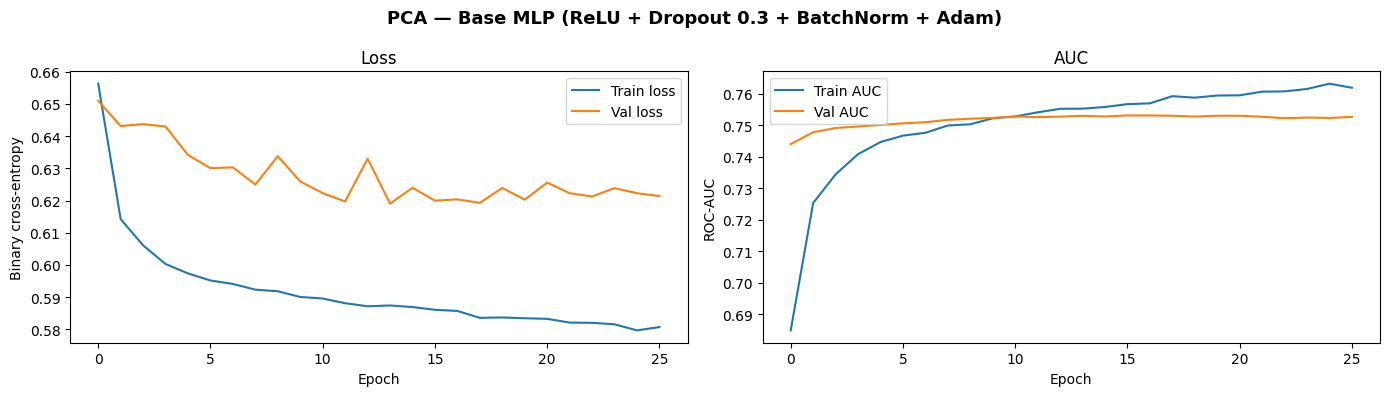

In [36]:
plot_training_curves(history_base_pca,
                     title="PCA — Base MLP (ReLU + Dropout 0.3 + BatchNorm + Adam)")

Even with dimensionality reduction, we can still see overfitting as the gap between train and val loss is big.

In [37]:
metrics_base_pca_val  = evaluate_keras_model(base_model_pca, X_val_pca_arr,  y_val_arr,  split_name="Val  (PCA)")
metrics_base_pca_test = evaluate_keras_model(base_model_pca, X_test_pca_arr, y_test_arr, split_name="Test (PCA)")


  Val  (PCA) — threshold = 0.3
  ROC-AUC : 0.7531
  PR-AUC  : 0.2334

                precision    recall  f1-score   support

No Default (0)       0.98      0.30      0.45     42402
   Default (1)       0.10      0.93      0.19      3724

      accuracy                           0.35     46126
     macro avg       0.54      0.62      0.32     46126
  weighted avg       0.91      0.35      0.43     46126


  Test (PCA) — threshold = 0.3
  ROC-AUC : 0.7544
  PR-AUC  : 0.2394

                precision    recall  f1-score   support

No Default (0)       0.98      0.29      0.45     42402
   Default (1)       0.10      0.93      0.19      3724

      accuracy                           0.35     46126
     macro avg       0.54      0.61      0.32     46126
  weighted avg       0.91      0.35      0.43     46126



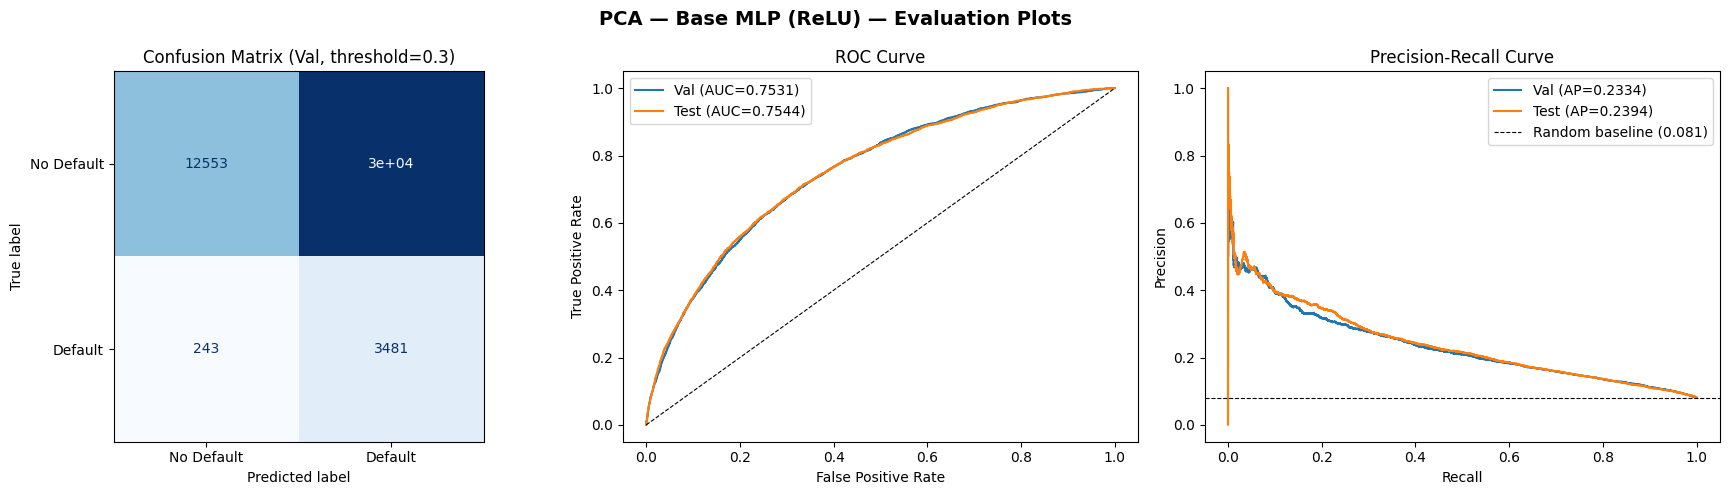

In [38]:
plot_evaluation_keras(base_model_pca, X_val_pca_arr, y_val_arr, X_test_pca_arr, y_test_arr,
                      title_prefix="PCA — Base MLP (ReLU)")

Our model is predicting many defaults and that is why recall is big, but this is not ideal, as precision is terrible, making the f1-score low.

## 15. PCA — Leaky ReLU MLP

Same as Section 5 (Leaky ReLU) but trained on PCA features.  
The dead-neuron motivation for Leaky ReLU applies equally here — PCA components
are real-valued and can be negative, so the same risk of zero-gradient neurons exists.

In [39]:
leaky_model_pca = build_mlp_leaky_relu(
    N_FEATURES_PCA, hidden_units=(128, 64),
    dropout_rate=0.3, use_batchnorm=True, learning_rate=0.001, alpha=0.1
)

early_stop_leaky_pca = EarlyStopping(
    monitor='val_auc', patience=10, mode='max',
    restore_best_weights=True, verbose=1
)

print("Training Leaky ReLU MLP on PCA data...")
t0 = time.time()

history_leaky_pca = leaky_model_pca.fit(
    X_train_pca_arr, y_train_arr,
    validation_data=(X_val_pca_arr, y_val_arr),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop_leaky_pca],
    class_weight=CLASS_WEIGHT,
    verbose=1
)

train_time_leaky_pca = time.time() - t0
print(f"\nTraining time: {train_time_leaky_pca:.1f}s")

Training Leaky ReLU MLP on PCA data...
Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - auc: 0.6923 - loss: 0.6491 - val_auc: 0.7445 - val_loss: 0.6410
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7278 - loss: 0.6127 - val_auc: 0.7481 - val_loss: 0.6389
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.7377 - loss: 0.6028 - val_auc: 0.7495 - val_loss: 0.6281
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7424 - loss: 0.5987 - val_auc: 0.7505 - val_loss: 0.6265
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.7444 - loss: 0.5969 - val_auc: 0.7508 - val_loss: 0.6307
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7462 - loss: 0.5953 - val_auc: 0.7512 - val_loss: 0.6261
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7483 - loss: 0.5937 - val_auc: 0.7518 - val_loss: 0.6257
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7486 - loss: 0.5935 - val_auc: 0.7517 - val_loss: 0.6231
Epoch 9/

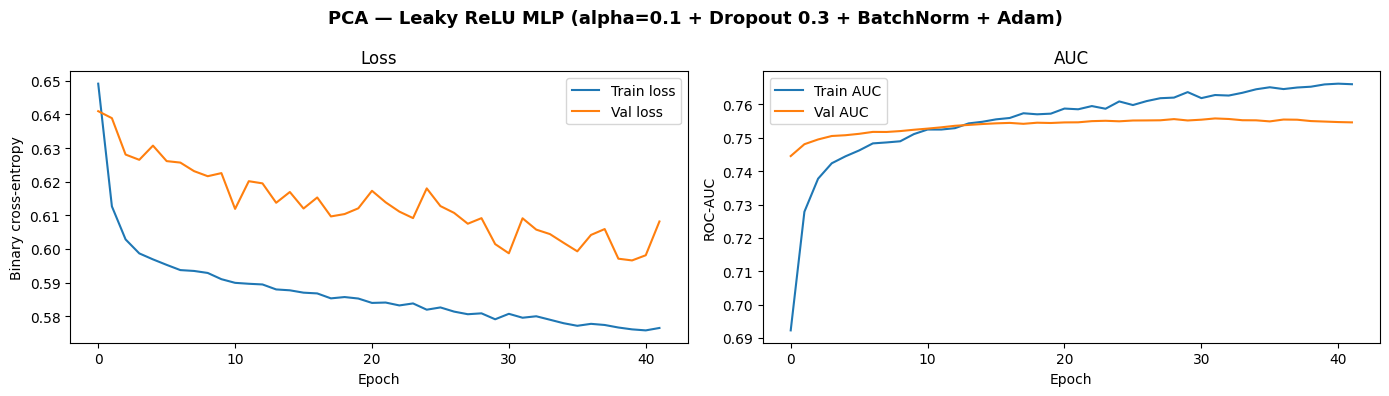

In [40]:
plot_training_curves(history_leaky_pca,
                     title="PCA — Leaky ReLU MLP (alpha=0.1 + Dropout 0.3 + BatchNorm + Adam)")

Slighly less overfitted than the ReLu version, but still not ideal.

In [41]:
metrics_leaky_pca_val  = evaluate_keras_model(leaky_model_pca, X_val_pca_arr,  y_val_arr,  split_name="Val  (PCA)")
metrics_leaky_pca_test = evaluate_keras_model(leaky_model_pca, X_test_pca_arr, y_test_arr, split_name="Test (PCA)")


  Val  (PCA) — threshold = 0.3
  ROC-AUC : 0.7558
  PR-AUC  : 0.2377

                precision    recall  f1-score   support

No Default (0)       0.98      0.31      0.47     42402
   Default (1)       0.11      0.93      0.19      3724

      accuracy                           0.36     46126
     macro avg       0.54      0.62      0.33     46126
  weighted avg       0.91      0.36      0.45     46126


  Test (PCA) — threshold = 0.3
  ROC-AUC : 0.7557
  PR-AUC  : 0.2382

                precision    recall  f1-score   support

No Default (0)       0.98      0.31      0.47     42402
   Default (1)       0.11      0.93      0.19      3724

      accuracy                           0.36     46126
     macro avg       0.54      0.62      0.33     46126
  weighted avg       0.91      0.36      0.45     46126



Just a small improvement on the "No Default" f1-score (2 p.p.). But again we have a good precision in class 0 and good recall in class 1, so the model is good at predicting when it is not a "Default" and catching "No Default", but it is not suitable at predicting "No Default" and catching "Default".

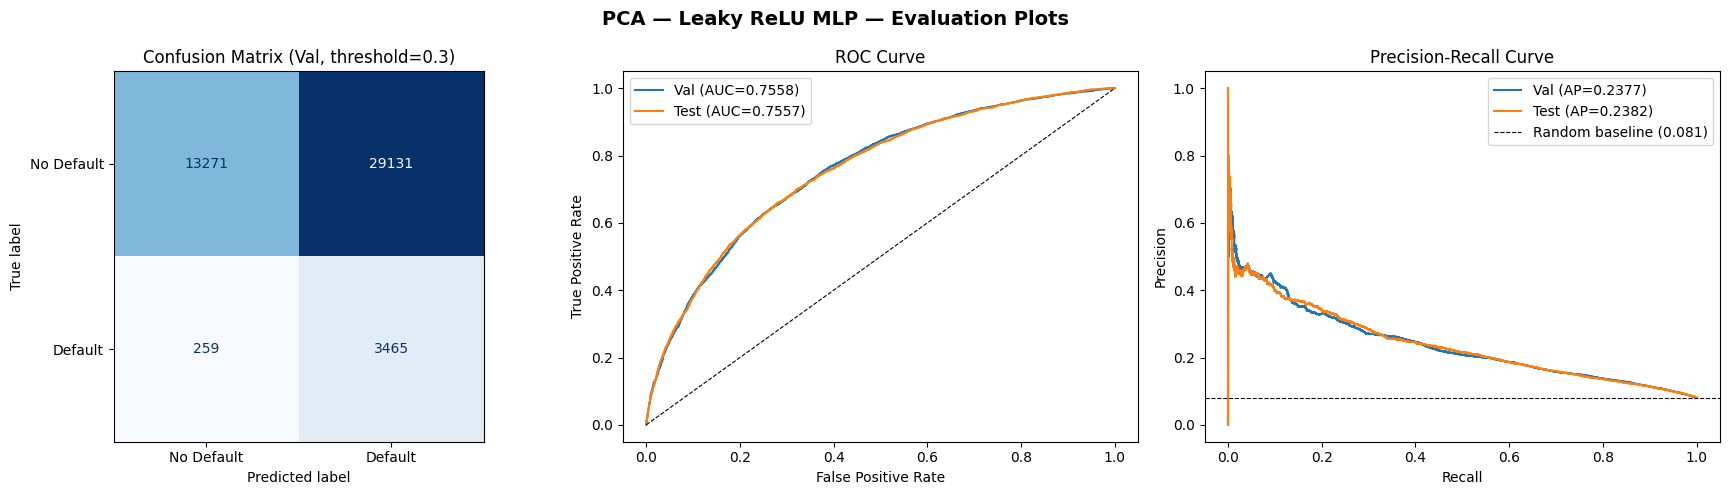

In [42]:
plot_evaluation_keras(leaky_model_pca, X_val_pca_arr, y_val_arr, X_test_pca_arr, y_test_arr,
                      title_prefix="PCA — Leaky ReLU MLP")

## 16. PCA — Best Configuration (Original & SMOTE)

We retrain the best configuration identified in the hyperparameter sweep (Section 6)
on the PCA data, both on the original class-weighted training set and the SMOTE-resampled
set.

This mirrors Section 8 (SMOTE comparison on original features), giving us four
comparable training scenarios:

| Training data | Features | Section |
|---|---|---|
| Original + class_weight | Original | 8 |
| SMOTE | Original | 8 |
| Original + class_weight | PCA | 16 |
| SMOTE | PCA | 16 |

In [43]:
def train_best_mlp_pca(X_train_data, y_train_data, cw=None, label=""):
    """Train the best sweep config on PCA data. cw = class_weight dict or None (for SMOTE)."""
    model = build_mlp_leaky_relu(
        N_FEATURES_PCA,
        hidden_units=BEST_UNITS,
        dropout_rate=BEST_DROPOUT,
        use_batchnorm=True,
        learning_rate=BEST_LR,
        alpha=0.1
    )
    es = EarlyStopping(monitor='val_auc', patience=10, mode='max',
                       restore_best_weights=True, verbose=0)
    print(f"Training best MLP (PCA) on {label} set (n={len(X_train_data):,})...")
    t0 = time.time()
    hist = model.fit(
        X_train_data, y_train_data,
        validation_data=(X_val_pca_arr, y_val_arr),
        epochs=100,
        batch_size=1024,
        callbacks=[es],
        class_weight=cw,
        verbose=0
    )
    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s")
    return model, hist, elapsed


best_pca_orig,  hist_pca_orig,  time_pca_orig  = train_best_mlp_pca(
    X_train_pca_arr, y_train_arr,
    cw=CLASS_WEIGHT, label="Original (class_weight)"
)
best_pca_smote, hist_pca_smote, time_pca_smote = train_best_mlp_pca(
    X_train_smote_pca_arr, y_train_smote_arr,
    cw=None, label="SMOTE (balanced)"
)

Training best MLP (PCA) on Original (class_weight) set (n=215,253)...
  Done in 99.9s
Training best MLP (PCA) on SMOTE (balanced) set (n=395,752)...
  Done in 32.0s


In [44]:
# SMOTE comparison table on PCA data
rows_pca = []
for model, label in [(best_pca_orig, "PCA — Original"), (best_pca_smote, "PCA — SMOTE")]:
    for X, y, split in [
        (X_val_pca_arr,  y_val_arr,  "Val"),
        (X_test_pca_arr, y_test_arr, "Test")
    ]:
        y_prob = model.predict(X, verbose=0).ravel()
        y_pred = (y_prob >= 0.3).astype(int)
        from sklearn.metrics import precision_score, recall_score, f1_score
        rows_pca.append({
            "Model"         : label,
            "Split"         : split,
            "ROC-AUC"       : round(roc_auc_score(y, y_prob), 4),
            "PR-AUC"        : round(average_precision_score(y, y_prob), 4),
            "Precision (1)" : round(precision_score(y, y_pred, pos_label=1, zero_division=0), 4),
            "Recall (1)"    : round(recall_score(y, y_pred, pos_label=1), 4),
            "F1 (1)"        : round(f1_score(y, y_pred, pos_label=1), 4),
        })

smote_pca_df = pd.DataFrame(rows_pca)
print("=== PCA — SMOTE vs Original comparison ===")
display(smote_pca_df)

=== PCA — SMOTE vs Original comparison ===


,Model,Split,ROC-AUC,PR-AUC,Precision (1),Recall (1),F1 (1)
0,PCA — Original,Val,0.7542,0.2341,0.1102,0.9127,0.1966
1,PCA — Original,Test,0.7550,0.2377,0.1098,0.9098,0.1960
2,PCA — SMOTE,Val,0.7394,0.2163,0.1156,0.8714,0.2042
3,PCA — SMOTE,Test,0.7434,0.2173,0.1155,0.8754,0.2041


On our PCA data, SMOTE worked better than in our past attempt. Still we are looking at ~20% f1-score, which is bad.

## 17. PCA vs Original Features — Comprehensive Comparison

This section directly answers the key question: **does dimensionality reduction via PCA
improve, hurt, or leave unchanged the MLP's predictive performance?**

We compare equivalent model configurations trained on original vs PCA features
on the validation set. The test set is only shown for the final best model.

Potential outcomes and their interpretation:
- **PCA ≈ Original:** The removed variance components were noise; PCA is lossless
  for this task. Prefer PCA for faster training and lower memory.
- **PCA < Original:** The discarded components (bottom 5% variance) contained
  discriminative signal — the MLP was using fine-grained feature interactions that
  PCA collapsed. Stick with original features.
- **PCA > Original:** PCA removed noise that was causing overfitting, effectively
  acting as an additional regulariser. This would support using PCA in production.

In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

def quick_metrics_pca(model, X_val, name, threshold=0.3):
    """Compute val-set metrics for the PCA comparison table."""
    y_prob = model.predict(X_val, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model"        : name,
        "Features"     : "PCA" if "PCA" in name else "Original",
        "Val ROC-AUC"  : round(roc_auc_score(y_val_arr, y_prob), 4),
        "Val PR-AUC"   : round(average_precision_score(y_val_arr, y_prob), 4),
        "Precision (1)": round(precision_score(y_val_arr, y_pred, pos_label=1, zero_division=0), 4),
        "Recall (1)"   : round(recall_score(y_val_arr, y_pred, pos_label=1), 4),
        "F1 (1)"       : round(f1_score(y_val_arr, y_pred, pos_label=1), 4),
    }

comparison_rows = [
    # Original feature models
    quick_metrics_pca(base_model,       X_val_arr,     "Base MLP ReLU — Original"),
    quick_metrics_pca(leaky_model,      X_val_arr,     "Leaky ReLU — Original"),
    quick_metrics_pca(best_model_orig,  X_val_arr,     "Best config (orig data) — Original"),
    quick_metrics_pca(best_model_smote, X_val_arr,     "Best config (SMOTE) — Original"),
    # PCA models
    quick_metrics_pca(base_model_pca,   X_val_pca_arr, "Base MLP ReLU — PCA"),
    quick_metrics_pca(leaky_model_pca,  X_val_pca_arr, "Leaky ReLU — PCA"),
    quick_metrics_pca(best_pca_orig,    X_val_pca_arr, "Best config (orig data) — PCA"),
    quick_metrics_pca(best_pca_smote,   X_val_pca_arr, "Best config (SMOTE) — PCA"),
]

comparison_df = pd.DataFrame(comparison_rows).sort_values("Val ROC-AUC", ascending=False).reset_index(drop=True)
print("=== PCA vs Original — Full Comparison (Val set, sorted by AUC) ===")
display(comparison_df)

=== PCA vs Original — Full Comparison (Val set, sorted by AUC) ===


,Model,Features,Val ROC-AUC,Val PR-AUC,Precision (1),Recall (1),F1 (1)
0,Best config (orig data) — Original,Original,0.7567,0.2385,0.3511,0.1643,0.2239
1,Leaky ReLU — Original,Original,0.7566,0.2366,0.1077,0.9213,0.1928
2,Base MLP ReLU — Original,Original,0.7558,0.2368,0.1077,0.9253,0.1930
3,Leaky ReLU — PCA,PCA,0.7558,0.2377,0.1063,0.9305,0.1908
4,Best config (orig data) — PCA,PCA,0.7542,0.2341,0.1102,0.9127,0.1966
5,Base MLP ReLU — PCA,PCA,0.7531,0.2334,0.1044,0.9347,0.1879
6,Best config (SMOTE) — PCA,PCA,0.7394,0.2163,0.1156,0.8714,0.2042
7,Best config (SMOTE) — Original,Original,0.7392,0.2150,0.1168,0.8676,0.2059


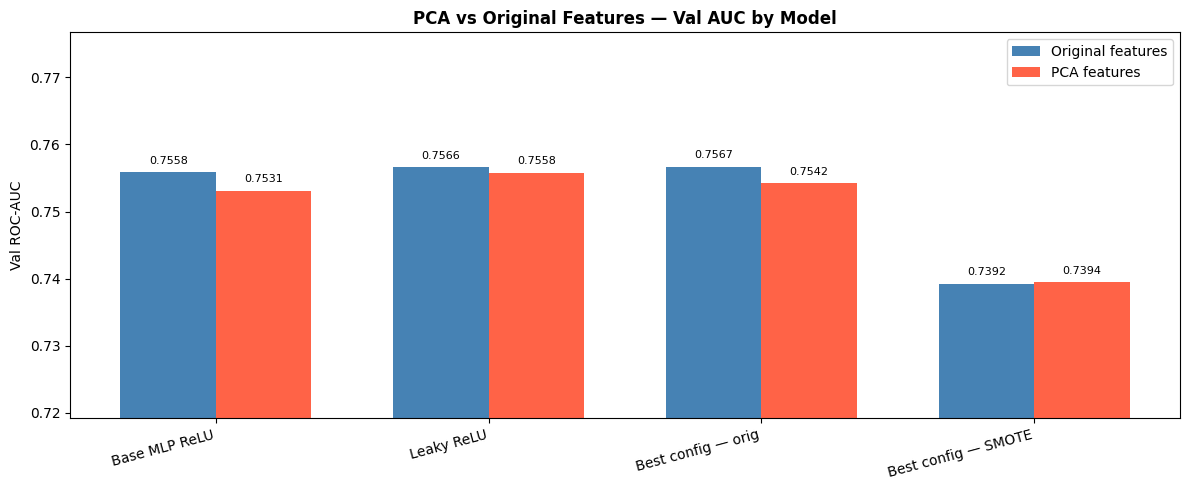

In [46]:
# Grouped bar chart: AUC by model pair (Original vs PCA)
labels_pairs = [
    ("Base MLP ReLU",          base_model,       X_val_arr,     base_model_pca,   X_val_pca_arr),
    ("Leaky ReLU",             leaky_model,      X_val_arr,     leaky_model_pca,  X_val_pca_arr),
    ("Best config — orig",     best_model_orig,  X_val_arr,     best_pca_orig,    X_val_pca_arr),
    ("Best config — SMOTE",    best_model_smote, X_val_arr,     best_pca_smote,   X_val_pca_arr),
]

orig_aucs = [roc_auc_score(y_val_arr, m.predict(X, verbose=0).ravel())
             for _, m, X, _, _ in labels_pairs]
pca_aucs  = [roc_auc_score(y_val_arr, m.predict(X, verbose=0).ravel())
             for _, _, _, m, X in labels_pairs]
pair_names = [l for l, *_ in labels_pairs]

x = np.arange(len(pair_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, orig_aucs, width, label='Original features', color='steelblue')
bars2 = ax.bar(x + width/2, pca_aucs,  width, label='PCA features',      color='tomato')

for bar, val in zip(list(bars1) + list(bars2), orig_aucs + pca_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=15, ha='right')
ax.set_ylabel("Val ROC-AUC")
ax.set_title("PCA vs Original Features — Val AUC by Model", fontweight='bold')
ax.legend()
ax.set_ylim(min(orig_aucs + pca_aucs) - 0.02, max(orig_aucs + pca_aucs) + 0.02)
plt.tight_layout()
plt.show()

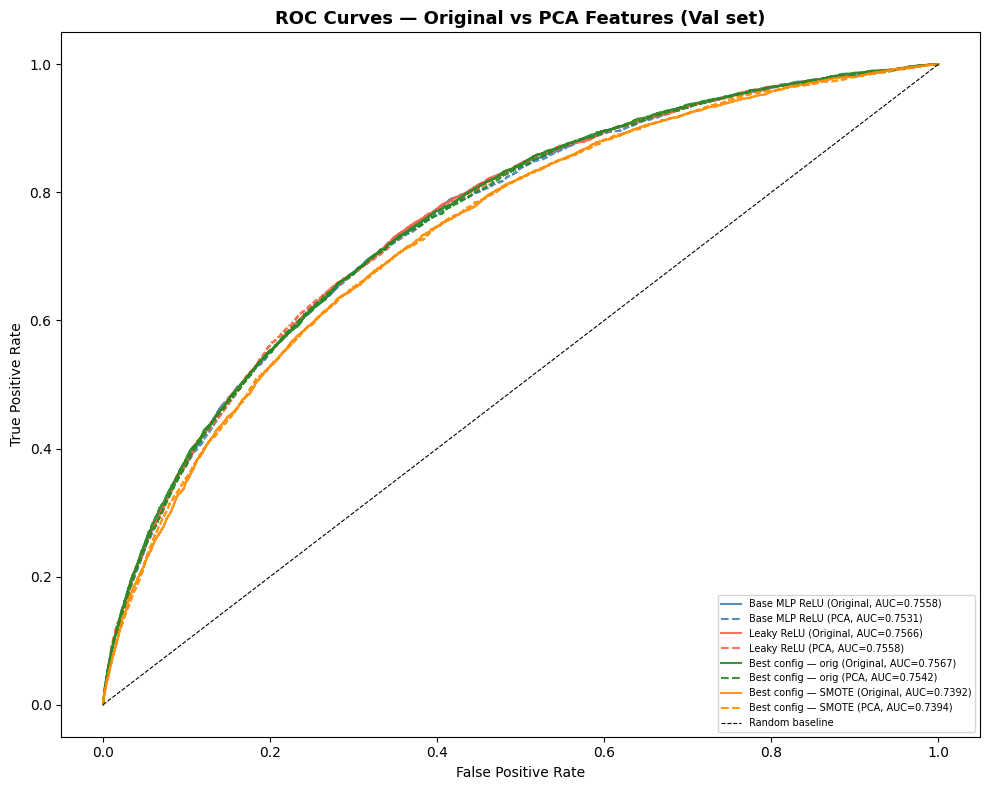

In [47]:
# ROC curve overlay — all 8 models on the validation set
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title("ROC Curves — Original vs PCA Features (Val set)", fontsize=13, fontweight='bold')

styles = {
    "Original": {"linestyle": "-",  "alpha": 0.9},
    "PCA"     : {"linestyle": "--", "alpha": 0.9},
}
colors = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

model_pairs = [
    ("Base MLP ReLU",       base_model,       X_val_arr,     base_model_pca,   X_val_pca_arr,   colors[0]),
    ("Leaky ReLU",          leaky_model,      X_val_arr,     leaky_model_pca,  X_val_pca_arr,   colors[1]),
    ("Best config — orig",  best_model_orig,  X_val_arr,     best_pca_orig,    X_val_pca_arr,   colors[2]),
    ("Best config — SMOTE", best_model_smote, X_val_arr,     best_pca_smote,   X_val_pca_arr,   colors[3]),
]

for name, m_orig, X_orig, m_pca, X_pca, color in model_pairs:
    for m, X, feat_label in [(m_orig, X_orig, "Original"), (m_pca, X_pca, "PCA")]:
        y_prob = m.predict(X, verbose=0).ravel()
        fpr, tpr, _ = roc_curve(y_val_arr, y_prob)
        auc = roc_auc_score(y_val_arr, y_prob)
        ax.plot(fpr, tpr, color=color,
                linestyle=styles[feat_label]["linestyle"],
                alpha=styles[feat_label]["alpha"],
                label=f"{name} ({feat_label}, AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

In [48]:
# Save PCA comparison results
comparison_df.to_csv(f"{MODEL_DIR}/mlp_pca_vs_original_comparison.csv", index=False)
smote_pca_df.to_csv(f"{MODEL_DIR}/mlp_pca_smote_comparison.csv",        index=False)

# Save best PCA model
best_pca_auc_orig  = roc_auc_score(y_val_arr, best_pca_orig.predict(X_val_pca_arr,  verbose=0).ravel())
best_pca_auc_smote = roc_auc_score(y_val_arr, best_pca_smote.predict(X_val_pca_arr, verbose=0).ravel())
best_pca_model = best_pca_orig if best_pca_auc_orig >= best_pca_auc_smote else best_pca_smote
best_pca_model.save(f"{MODEL_DIR}/mlp_pca_best.keras")

print("Saved PCA comparison CSVs and best PCA model.")
print(f"\nBest PCA model val AUC  : {max(best_pca_auc_orig, best_pca_auc_smote):.4f}")
print(f"Best Orig model val AUC : {summary_df.iloc[0]['Val ROC-AUC']:.4f}")
delta = max(best_pca_auc_orig, best_pca_auc_smote) - summary_df.iloc[0]['Val ROC-AUC']
direction = "higher" if delta > 0 else "lower"
print(f"\nPCA vs Original delta   : {delta:+.4f} ({direction} with PCA)")

Saved PCA comparison CSVs and best PCA model.

Best PCA model val AUC  : 0.7542
Best Orig model val AUC : 0.7567

PCA vs Original delta   : -0.0025 (lower with PCA)


Our best model had a val AUC of ~76%. On our imbalanced data, this is not a good result. This model used 0.3 Dropout, BatchNorm and Early Stopping. Interestingly, we achieved a 0,0017 gap between val loss and train loss, which was something that other models were not even close.